## Outcome devaluation and habit expression

In this paper authors showed that when you train two actions concurrently (need to still define this group in terms of simulation parameters and make some predictions about what will happen), neither of them gets expressed as habit. When you train and devalue only 1, you can show a habit. I will try and recreate the simulations. 

![alt text](img1_exp_design.png)


This is the pattern of behaviour from the paper:

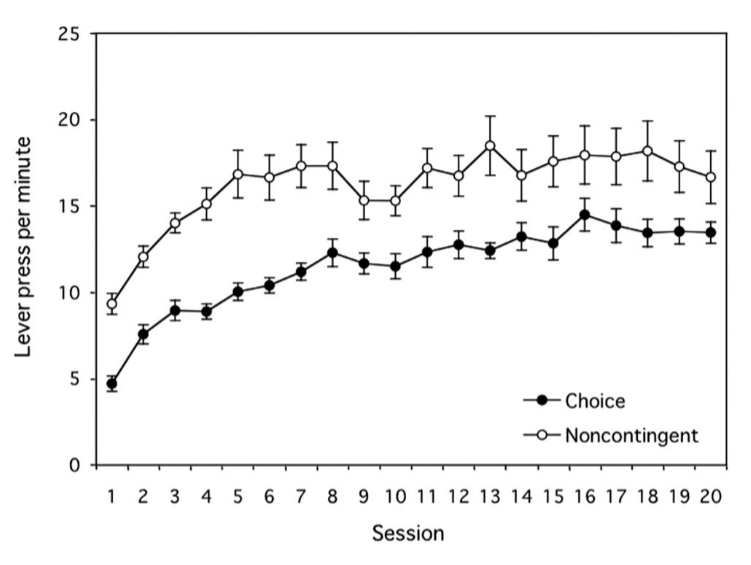

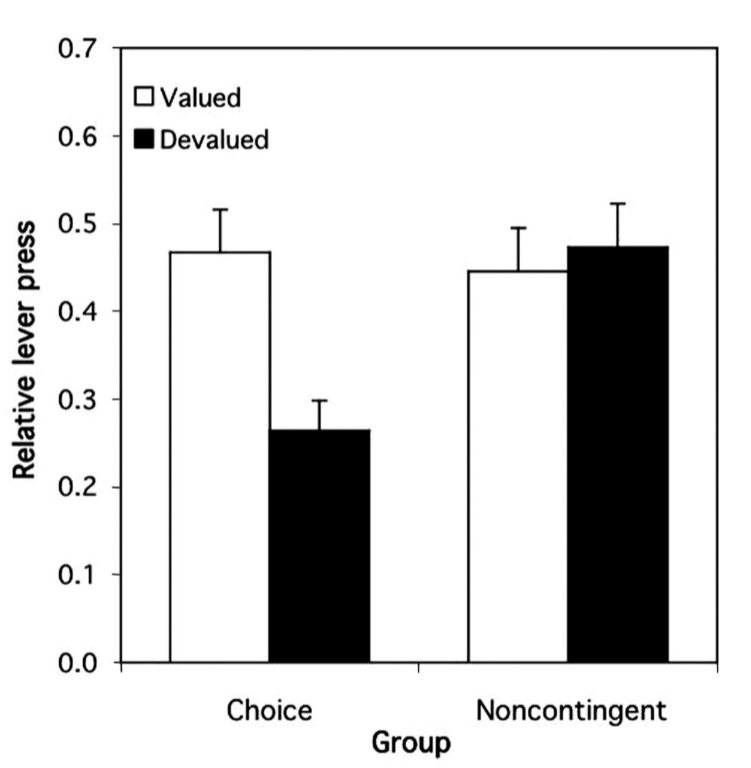



## Classes

In [ ]:
# %matplotlib widget
import matplotlib.pyplot as plt
# import ipywidget/s
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])



		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context_sarah(self,t,tau, likelihood_policies, posterior_policies, prior_context):
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t]

			posterior_context = (posterior_policies * self.ln(likelihood_policies)).sum(axis=0) \
								- (posterior_policies * self.ln(posterior_policies)).sum(axis=0)\
								+ (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0))\
								+ self.ln(prior_context)                            
		else:
			posterior_context = self.ln(prior_context)

		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		self.posterior_context[tau,t] = posterior_context


		return posterior_context
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau+1,t,:,:,k].round(3))


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state):
		regime = self.training_protocol[tau]
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		return self.rewards[tau,t]
	

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():

	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr

	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]

	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			if tau == 21:
				a = 0
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				#    nb=2, 
				#    ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, habit_exception=None):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = na - 1
	ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*na + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(na+1)]*(na+1)).transpose([1,0,2])[:,:,:na]

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()

	# state_trans_matrix = world.agent.state_transition_matrix[:,:,-1,0]
	prior_rewards_matrix = world.agent.prior_rewards[-1,-1,:,:,:]
	policy_prior_matrix = world.agent.prior_policies[-1,-1,:,:]

	return world, prior_rewards_matrix, policy_prior_matrix


def create_dataframe(TAU,T,agent):

			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(2)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(agent.npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)

#### Run simulations

### Group 2 - has 2 actions


Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1, A2 or ~A and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0    & 0    \\ 0    & 0.9  & 0    \\ 0.1  & 0.1 & 1 \end{bmatrix}, \begin{bmatrix} 0  & 0   & 0   \\ 0  & 0  & 0   \\ 1  & 1 & 1   \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is $\left[0.45,0.45,0.1\right]$ and during devaluation we again have 2 groups, with $p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$, $p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$



/tmp/ipykernel_378701/226209082.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels(["O2 devalued \n (noncontingent)", "O1 devalued \n (contingent)"],rotation=0, fontsize=14)


[Text(0.5, 0, 'context 1'), Text(1.5, 0, 'context 2')]

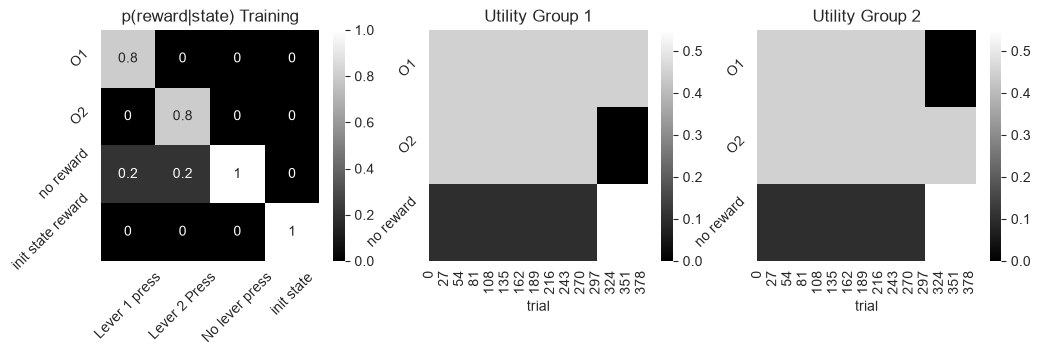

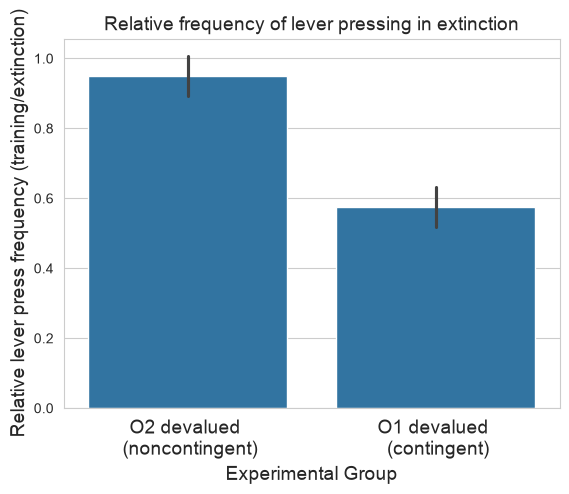

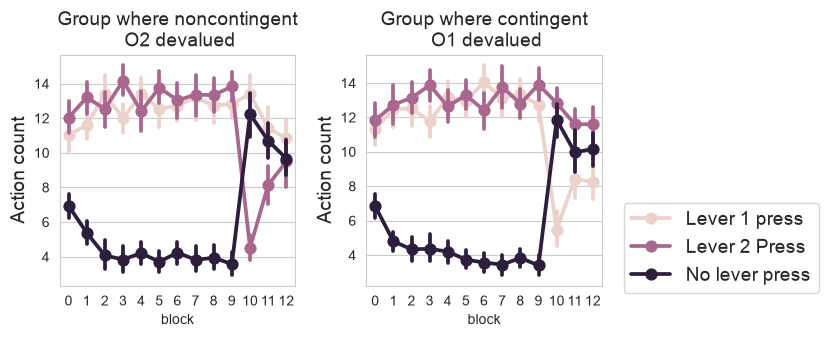

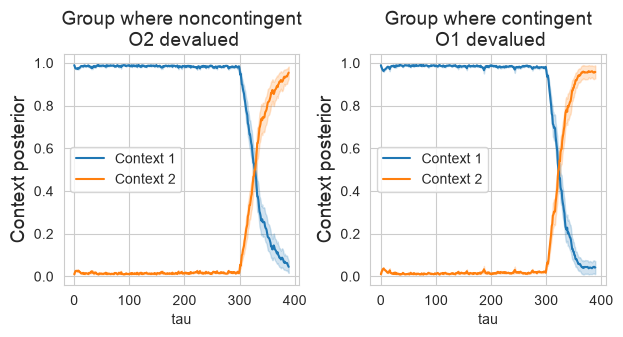

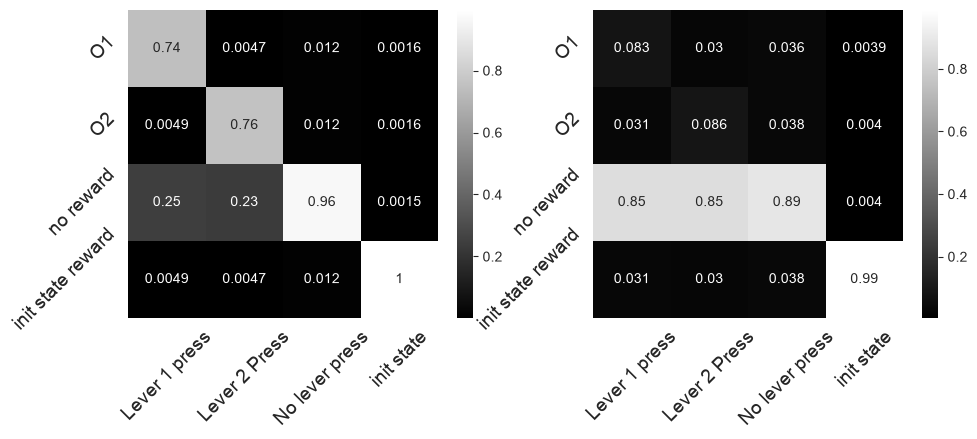

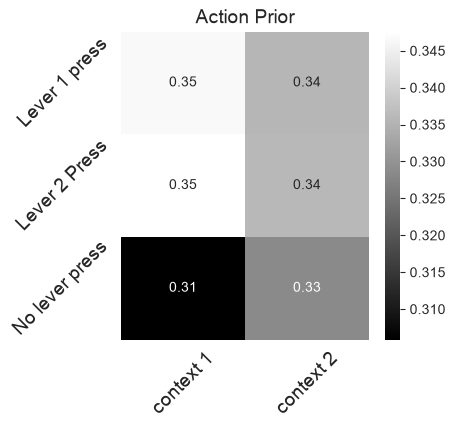

In [ ]:
np.random.seed(1)
reps = 30
n_blocks_train = 10
n_blocks_extinction = 3
block_length = 30
na=3
nr=4
ns=na+1
nc=2
n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 2
plt.close("all")
# utility_1 = [[0.495,0.495, 0.01], [0.98, 0.01, 0.01]]
utility_1 = [[0.45,0.45, 0.1], [0.45 + 0.45/2, 0, 0.1 + 0.45/2]]
utility_2 = [[0.45,0.45, 0.1], [0, 0.45 + 0.45/2, 0.1 + 0.45/2]]
# utility_1 = [[0.45,0.45, 0.1], [0.8, 0, 0.2]]
# utility_2 = [[0.45,0.45, 0.1], [0, 0.8, 0.2]]

""" HIGH REWARD CONTINGENCIES + higher preference for valued outcome
In this regime you get 
1. two contexts being inferred, due to high prediction error from extinction
2. some increase and then decrease in preference for valued action in extinction, due to the relatively higher motivation for the still valued outcome
3. This effect pressing for one action even more during initial extinction is even more pronounced if the animal habituates. It can also develop a preference for one lever over the other. 
"""
rho=0.9
p = 0.8
context_volatility=0.99
h=10000
habit_exception = None

""" same preference for valued outcome
# In this regime you get 
# 1. two contexts being inferred, due to high prediction error from extinction
# 2. a decrease for pressing overall due to higher preference for no reward
# 3. habituation reverses this trend and leads to sometimes higher overall press rate. 
"""

rho=0.9
p = 0.45
context_volatility=0.99
h=1000
habit_exception = None

""" LOWER REWARD CONTINGENCIES + higher preference for valued outcome
In this regime you get 
1. one contexts being inferred, due to lower prediction error during extinction
2. an initial increase and then decrease in valued action execution during extinction, due to now relatively higher preference for non-devalued outcome
3. If I increase habitual tendency, the overall pattern remains the same
"""
rho=0.6
p = 0.8
context_volatility=0.99
h=1000
habit_exception = None


""" LOWER REWARD CONTINGENCIES 
In this regime you get 
1. one contexts being inferred, due to lower prediction error during extinction
2. no action overexecution, but still pretty high responding for valued action.  
If we increase habitual tendency we get lower execution of no action and overexpression of valued action. 
"""
rho=0.6
p = 0.3
context_volatility=0.99
h=1000
habit_exception = 2


rho=0.8
p = 0.45
context_volatility=0.99
h=1000
habit_exception = 2
utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

Rho = np.stack([[[rho  , 0.0, 0.0, 0.0],
				 [0.0, rho  , 0.0, 0.0],
				 [1-rho, 1-rho, 1.0, 0.0],
				 [0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0],
				 [0, 0, 0, 0],
				 [1, 1, 1, 0],
				 [0, 0, 0, 1]]], axis=-1)

long_dfs = []
sim = 0
 

srm = np.zeros([nr,ns,nc,reps*2])
pcm = np.zeros([na,nc,reps*2])
for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):

		world, srm[:,:,:,sim], pcm[:,:,sim] = run_simulation(debug=False,utility=util, T=T, n_train=n_train, n_extinction=n_extinction, Rho=Rho, context_volatility=context_volatility, h=h, habit_exception=habit_exception)

		training_protocol = world.environment.training_protocol
		agent = world.agent

		long_df = create_dataframe(TAU, T, agent)
		long_dfs.append(long_df)

		sim += 1


dataframe = pd.concat(long_dfs)
matrices = {"reward_generation_matrix": srm.mean(axis=-1), "policy_prior_matrix": pcm.mean(axis=-1)}


p = {"action_legend_labels":["Lever 1 press", "Lever 2 Press", "No lever press"],
	 "state_legend_labels":["Lever 1 press", "Lever 2 Press", "No lever press","init state"],
	 "reward_legend_labels":["O1","O2","no reward", "init state reward"]}

fig, axes = plt.subplots(1,3,figsize=(12,3))

g = sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
# g = sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")
g.yaxis.set_ticklabels(p["reward_legend_labels"],rotation=45)
g.xaxis.set_ticklabels(p["state_legend_labels"],rotation=45)

g = sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[1])
g.yaxis.set_ticklabels(p["reward_legend_labels"][:-1],rotation=45)
g.set_xlabel("trial")

g = sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[2])
g.yaxis.set_ticklabels(p["reward_legend_labels"][:-1],rotation=45)
g.set_xlabel("trial")
# g.xaxis.set_ticklabels(p["state_legend_labels"],rotation=45)
for ax, title in zip(axes, ["p(reward|state) Training", "Utility Group 1", "Utility Group 2"]): # ,"p(reward|state) Degradation", "Block Type"
	ax.set_title(title)


""" Relative action counts in EXTINCTION """
df = dataframe.groupby(by=["experimental_group","sim","phase","t"])["action"].value_counts()
df_counts =  df.groupby(by=["experimental_group", "sim","phase","t"]).sum()
df = df/df_counts
relative_action = (df[:,:,"extinction",0])/(df[:,:,"training",0])
relative_action.head()
plt.figure()
g = sns.barplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group", y="count")
# sns.stripplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group",y="count",dodge=True)
g.xaxis.set_ticklabels(["O2 devalued \n (noncontingent)", "O1 devalued \n (contingent)"],rotation=0, fontsize=14)
g.set_ylabel("Relative lever press frequency (training/extinction)", fontsize=14)
g.set_xlabel("Experimental Group", fontsize=14)

plt.title("Relative frequency of lever pressing in extinction", fontsize=14)#"From paper: Relative frequence of valued (0) vs devalued (1) action")
# plt.ylim([0,0.7])

""" Action frequency in each experimental block"""
df = (dataframe.groupby(by=["experimental_group","sim","block","t"])["action"].value_counts()).reset_index()
plt.figure(figsize=(7,3))

plt.subplot(1,2,1)
plt.title("Group where noncontingent\n O2 devalued", fontsize=14)
g = sns.pointplot(data=df.query("experimental_group==0"), x="block",y="count",hue="action")
g.set_ylabel("Action count", fontsize=14)
g.legend(handles=g.get_legend_handles_labels()[0], labels=p["action_legend_labels"], fontsize=14)
g.get_legend().remove()
plt.subplot(1,2,2)
g = sns.pointplot(data=df.query("experimental_group==1"), x="block",y="count",hue="action")
g.set_ylabel("Action count", fontsize=14)
g.legend(handles=g.get_legend_handles_labels()[0], labels=p["action_legend_labels"], fontsize=14, bbox_to_anchor=[1.05, 0.4])
plt.title("Group where contingent\n O1 devalued", fontsize=14)

plt.subplots_adjust(wspace=0.3)


""" Context posterior """
plt.figure(figsize=(7,3))
plt.subplot(1,2,1)
sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
g.set_ylabel("Context posterior", fontsize=14)
plt.title("Group where noncontingent\n O2 devalued", fontsize=14)

plt.subplot(1,2,2)
g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
g.set_ylabel("Context posterior", fontsize=14)
plt.title("Group where contingent\n O1 devalued", fontsize=14)

plt.subplots_adjust(wspace=0.3)


""" Learned reward contingencies"""
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
g = sns.heatmap(matrices["reward_generation_matrix"][:,:,0],annot=True, cmap="gray")
g.yaxis.set_ticklabels(p["reward_legend_labels"],rotation=45, fontsize=14)
g.xaxis.set_ticklabels(p["state_legend_labels"],rotation=45, fontsize=14,)
plt.subplot(1,2,2)
g = sns.heatmap(matrices["reward_generation_matrix"][:,:,1],annot=True, cmap="gray")
g.yaxis.set_ticklabels(p["reward_legend_labels"],rotation=45, fontsize=14)
g.xaxis.set_ticklabels(p["state_legend_labels"],rotation=45, fontsize=14)


""" Learned policy prior"""
plt.figure(figsize=(4,4))
plt.subplot(1,1,1)
plt.title("Action Prior", fontsize=14)
g = sns.heatmap(matrices["policy_prior_matrix"],annot=True, cmap="gray")
g.yaxis.set_ticklabels(p["action_legend_labels"],rotation=45, fontsize=14)
g.xaxis.set_ticklabels(["context 1", "context 2"],rotation=45, fontsize=14)
# plt.subplot(1,2,2)
# sns.heatmap(agent.prior_policies_counts[-1,-1,:,1],annot=True)

# """Reinforcement schedule"""

# plt.figure()
# df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
# sns.barplot(data = df.query("phase == 'training' & t == 1"), y="count",hue="reward")

######################################################


# """                    Task setup                     """
# fig, axes = plt.subplots(1,5,figsize=(16,3))
# fig.suptitle("Experimental Setup", fontsize=14,y=1.05)

# sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
# sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")

# sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[2])
# sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[3])

# sns.lineplot(ax=axes[4], x=np.arange(n_blocks_train + n_blocks_extinction)+1,y=[0]*n_blocks_train + [1]*n_blocks_extinction,marker="o")
# axes[4].xaxis.set_major_locator(MultipleLocator(1))
# axes[4].yaxis.set_major_locator(MultipleLocator(1))

# for ax, title in zip(axes, ["p(outcome|state) Training","p(outcome|state) Degradation", "Utility Group 1", "Utility Group 2", "Block Type"]):
#     ax.set_title(title)



# """      Relative frequency of action in valued vs devalued group       """
# df = dataframe.groupby(by=["experimental_group", "sim","phase","t"])["action"].value_counts(normalize=True)
# relative_action = (df[:,:,"extinction",0])/(df[:,:,"training",0])
# plt.figure()
# sns.barplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group", y="proportion")
# sns.stripplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group", y="proportion",dodge=True)
# plt.title("From paper: Relative frequence of valued (0) vs devalued (1) action")
# # plt.ylim([0,1])



# """    Action frequency in each experimental block     """
# df = dataframe.groupby(by=["experimental_group", "sim","block","t"])["action"].value_counts()
# plt.figure()
# for group in [0,1]:
# 	plt.subplot(1,2,group+1)
# 	g = sns.pointplot(data=df.reset_index().query(f"experimental_group == {group}"),x="block",y="count", hue="action", errorbar="se")
# 	g.legend(handles = g.get_legend_handles_labels()[0], labels = ["L1","L2", "~L"], title="Action")
# 	g.set_title(f"O{(group == 0)+1} devalued group")



# """       Context posterior for each group      """
# plt.figure()
# df = dataframe
# plt.subplot(1,2,1)
# g = sns.lineplot(data=df.query("experimental_group == 0 & t==1"), x="tau", y="posterior_context_c0", errorbar="se")
# sns.lineplot(data=df.query("experimental_group == 0 & t==1"), x="tau", y="posterior_context_c1", errorbar="se")
# g.xaxis.set_major_locator(MultipleLocator(block_length*2))
# plt.subplot(1,2,2)
# g = sns.lineplot(data=df.query("experimental_group == 1 & t==1"), x="tau", y="posterior_context_c0", errorbar="se")
# sns.lineplot(data=df.query("experimental_group == 1 & t==1"), x="tau", y="posterior_context_c1", errorbar="se")
# g.xaxis.set_major_locator(MultipleLocator(block_length*2))


# """       Learned rewards distributions          """
# plt.figure()
# plt.subplot(1,2,1)
# sns.heatmap(agent.posterior_predictive_rewards[:,:,0],annot=True)
# plt.subplot(1,2,2)
# sns.heatmap(agent.posterior_predictive_rewards[:,:,1],annot=True)


# """        Learned policy prior                    """
# plt.figure()
# g = sns.heatmap(world.agent.prior_policies_counts[:,-1,:,0])
# g.set_title("Learned policy prior for context 0")
# g.xaxis.set_ticklabels(["L1","L2","~L"])

<Axes: ylabel='count'>

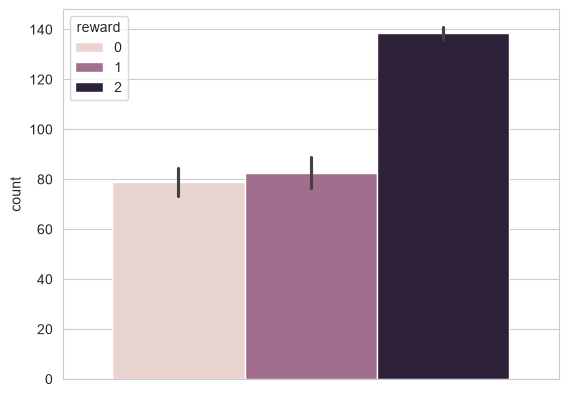

In [12]:
"""Reinforcement schedule"""
plt.figure()
df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
sns.barplot(data = df.query("phase == 'training' & t == 1"), y="count",hue="reward")

## Group 1 simulations

Group 1 has only 1 lever and hence two actiohsm pushing or not pushing the lever.  

Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1 or ~A1 and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0   \\ 0    & 0.5  \\ 0.1  & 0.5 \end{bmatrix}, \begin{bmatrix} 0  & 0   \\ 0  & 0  \\ 1  & 1 \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is

$$\left[0.45,0.45,0.1\right]$$

During devaluation we have 2 groups, one where the habit-associated outcome is devalued and one where the non-contingent outcome is devalued:

$$p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$$

$$p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$$

I can explore here building habit only over 1 action!

<Axes: ylabel='count'>

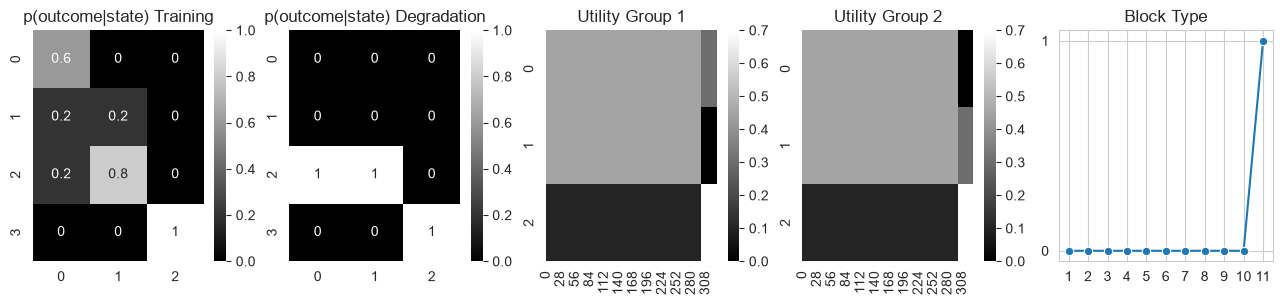

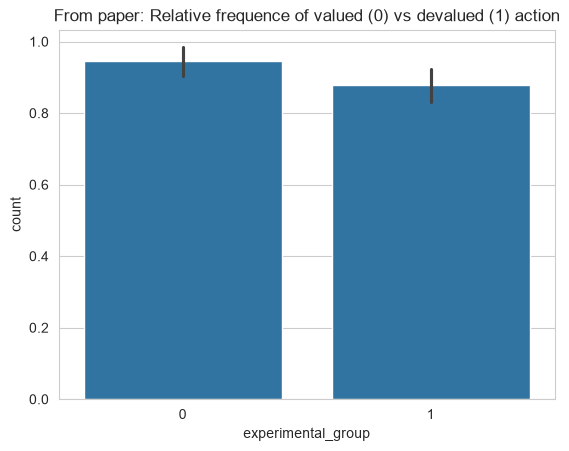

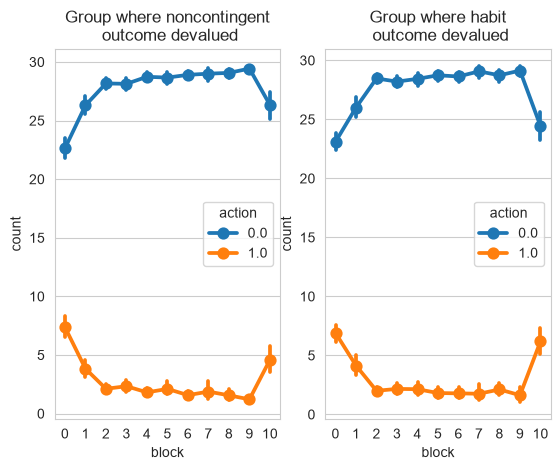

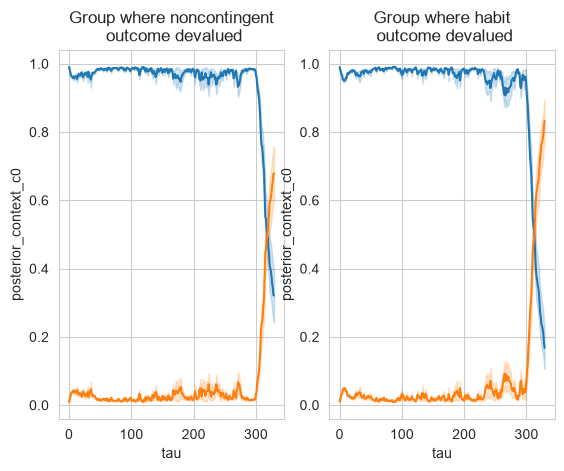

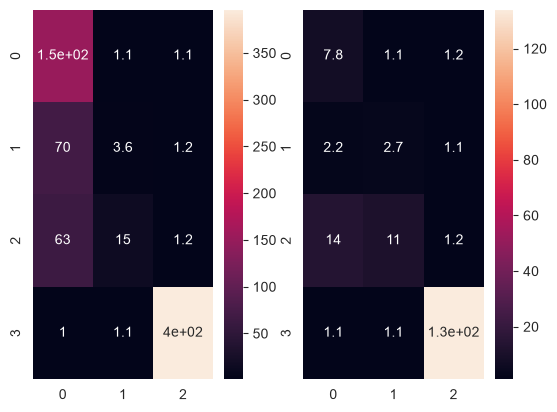

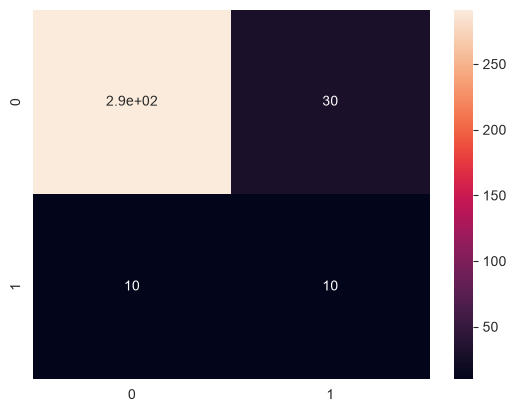

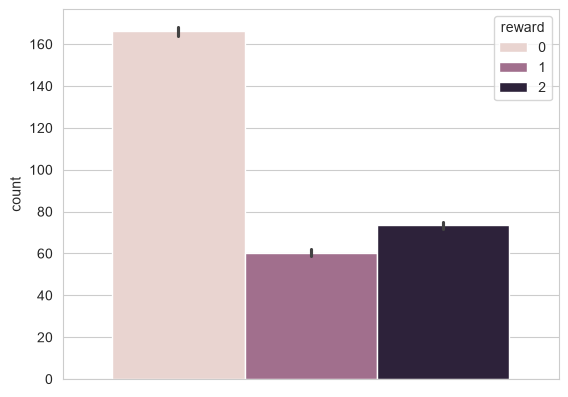

In [ ]:
# %matplotlib widget
import matplotlib.pyplot as plt
from scipy import stats
# import ipywidget/s
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])



		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context_sarah(self,t,tau, likelihood_policies, posterior_policies, prior_context):
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t]

			posterior_context = (posterior_policies * self.ln(likelihood_policies)).sum(axis=0) \
								- (posterior_policies * self.ln(posterior_policies)).sum(axis=0)\
								+ (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0))\
								+ self.ln(prior_context)                            
		else:
			posterior_context = self.ln(prior_context)

		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		self.posterior_context[tau,t] = posterior_context


		return posterior_context
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau+1,t,:,:,k].round(3))


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)

		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol

	
	def sample_reward(self, t, tau, state):
		regime = self.training_protocol[tau]
		self.rewards[tau,t] = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		return self.rewards[tau,t]
	

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():

	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr

	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]

	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			if tau == 21:
				a = 0
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				#    nb=2, 
				#    ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, habit_exception=None):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = na - 1
	ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*na + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(na+1)]*(na+1)).transpose([1,0,2])[:,:,:na]

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()

	return world 


def create_dataframe(TAU,T,agent):

			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(2)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(agent.npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)
		
np.random.seed(1)
reps = 30
n_blocks_train = 10
n_blocks_extinction = 1
block_length = 30

n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 2

### Working!
context_volatility=0.99
h= 10
habit_exception = 1
p = 0.3
utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]
Rho = np.stack([[[0.6, 0.0, 0.0],
				 [0.2, 0.2, 0.0],
				 [0.2, 0.8, 0.0],
				 [0.0, 0.0, 1.0]],
				[[0, 0, 0],
				 [0, 0, 0],
				 [1, 1, 0],
				 [0, 0, 1]]], axis=-1)




long_dfs = []
sim = 0

for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):

		world = run_simulation(debug=False,utility=util, na=2, T=T, n_train=n_train, n_extinction=n_extinction, Rho=Rho, context_volatility=context_volatility,h=h, habit_exception = habit_exception)

		training_protocol = world.environment.training_protocol
		agent = world.agent

		
		# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(2)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		ourcome_surpr_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			ourcome_surpr_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(agent.npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**ourcome_surpr_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		long_df = pd.DataFrame(long_df_dict)
		long_dfs.append(long_df)

		sim += 1


dataframe = pd.concat(long_dfs)
fig, axes = plt.subplots(1,5,figsize=(16,3))

sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")

sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[2])
sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[3])

sns.lineplot(ax=axes[4], x=np.arange(n_blocks_train + n_blocks_extinction)+1,y=[0]*n_blocks_train + [1]*n_blocks_extinction,marker="o")
axes[4].xaxis.set_major_locator(MultipleLocator(1))
axes[4].yaxis.set_major_locator(MultipleLocator(1))

for ax, title in zip(axes, ["p(outcome|state) Training","p(outcome|state) Degradation", "Utility Group 1", "Utility Group 2", "Block Type"]):
	ax.set_title(title)


""" Relative action counts in EXTINCTION """
df = dataframe.groupby(by=["experimental_group","sim","phase","t"])["action"].value_counts()
df_counts =  df.groupby(by=["experimental_group", "sim","phase","t"]).sum()
df = df/df_counts
relative_action = (df[:,:,"extinction",0])/(df[:,:,"training",0])
relative_action.head()
plt.figure()
sns.barplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group", y="count")
# sns.stripplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group",y="count",dodge=True)
plt.title("From paper: Relative frequence of valued (0) vs devalued (1) action")
# plt.ylim([0,0.7])

""" Action frequency in each experimental block"""
df = (dataframe.groupby(by=["experimental_group","sim","block","t"])["action"].value_counts()).reset_index()
plt.figure()
plt.subplot(1,2,1)
plt.title("Group where noncontingent\n outcome devalued")
sns.pointplot(data=df.query("experimental_group==0"), x="block",y="count",hue="action")
# plt.figure()
plt.subplot(1,2,2)
sns.pointplot(data=df.query("experimental_group==1"), x="block",y="count",hue="action")
plt.title("Group where habit\n outcome devalued")

""" Context posterior """
plt.figure()
plt.subplot(1,2,1)
sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c0", errorbar="se")
sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c1", errorbar="se")
plt.title("Group where noncontingent\n outcome devalued")

plt.subplot(1,2,2)
sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c0", errorbar="se")
sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c1", errorbar="se")
plt.title("Group where habit\n outcome devalued")

""" Learned reward contingencies"""
plt.figure()
plt.subplot(1,2,1)
sns.heatmap(agent.prior_rewards_counts[-1,-1,:,:,0],annot=True)
plt.subplot(1,2,2)
sns.heatmap(agent.prior_rewards_counts[-1,-1,:,:,1],annot=True)

""" Learned policy prior"""
plt.figure()
plt.subplot(1,1,1)
sns.heatmap(agent.prior_policies_counts[-1,-1,:,:],annot=True)
# plt.subplot(1,2,2)
# sns.heatmap(agent.prior_policies_counts[-1,-1,:,1],annot=True)

"""Reinforcement schedule"""
plt.figure()
df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
sns.barplot(data = df.query("phase == 'training' & t == 1"), y="count",hue="reward")



### Legacy plots from group  2

In [ ]:
df = dataframe.copy()
df.loc[df["t"]==1,"action"] = df.loc[df["t"]==0, "action"].to_numpy()

''''''''''''''''''
plt.figure(figsize=(10,3),dpi=300)
plt.subplot(1,3,1)
g = sns.scatterplot(data=df.query("experimental_group == 0 & t == 1"), x="tau",y="outcome_surprise_c0", hue="action", style="reward")
g.legend(bbox_to_anchor=(1,1))
g.set_ylim([-5,-1])
''''''''''''''''''
plt.figure(figsize=(10,3),dpi=300)
plt.subplot(1,3,1)
g = sns.scatterplot(data=df.query("t == 1 & phase == 'extinction'"), x="tau",y="outcome_surprise_c0", hue="experimental_group", style="action")
g.legend(bbox_to_anchor=(1,1))
dataframe.columns
plt.show()
df.query("experimental_group == 0 & t == 1 & action == 0").shape



''''''''''''''''''
plt.figure(figsize=(10,3),dpi=300)
plt.subplot(1,3,1)
g = sns.scatterplot(data=df.query("t == 1 & phase == 'extinction'"), x="tau",y="outcome_surprise_c0", hue="experimental_group", style="action")
g.legend(bbox_to_anchor=(1,1))
dataframe.columns
plt.show()
df.query("experimental_group == 0 & t == 1 & action == 0").shape

## Single lever 

/tmp/ipykernel_1024712/1198386181.py:940: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
/tmp/ipykernel_1024712/1198386181.py:919: OptimizeWarning: Covariance of the parameters could not be estimated
  context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
/tmp/ipykernel_1024712/1198386181.py:1045: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=relative_action.reset_index().astype({"experimental_group":"category"}).query("action == 0"),
/tmp/ipykernel_1024712/1198386181.py:1047: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. O

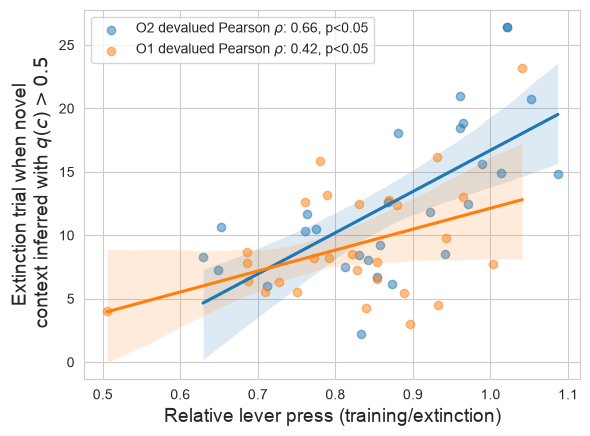

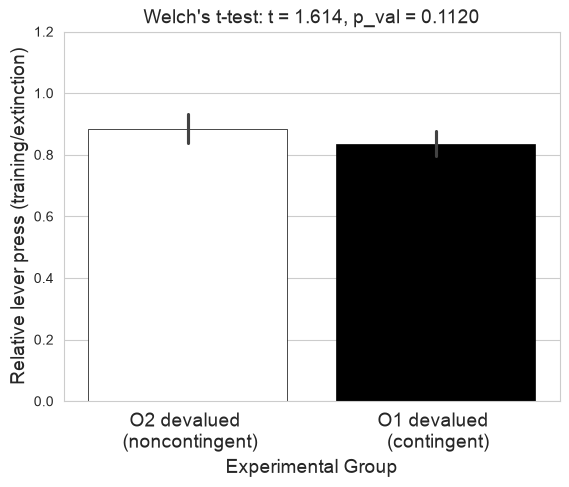

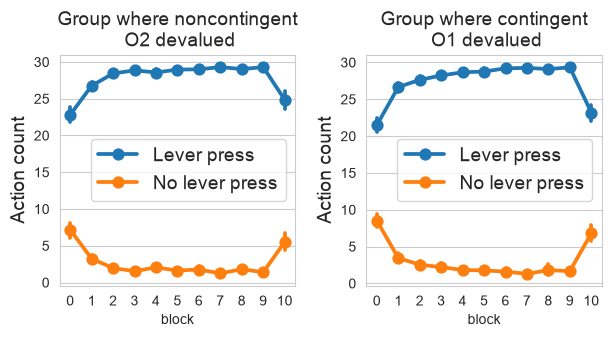

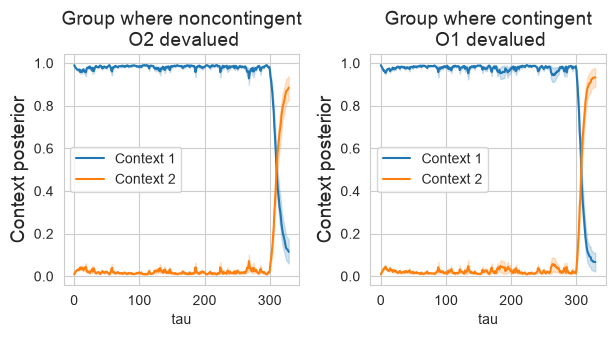

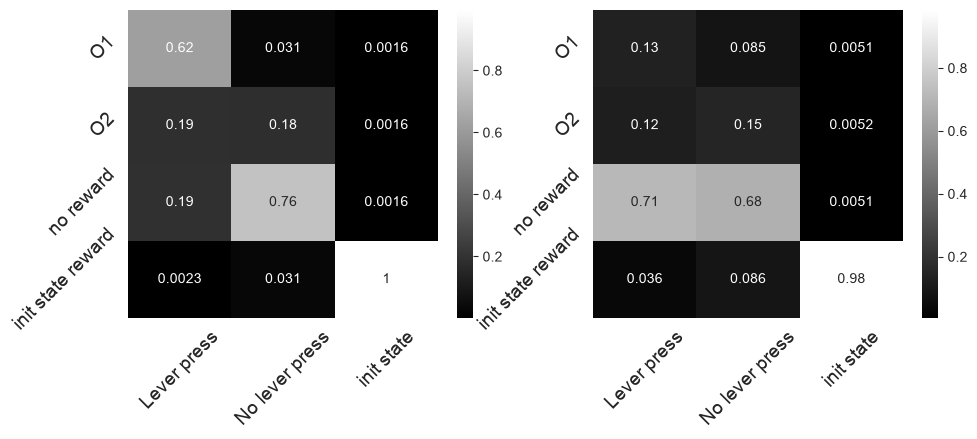

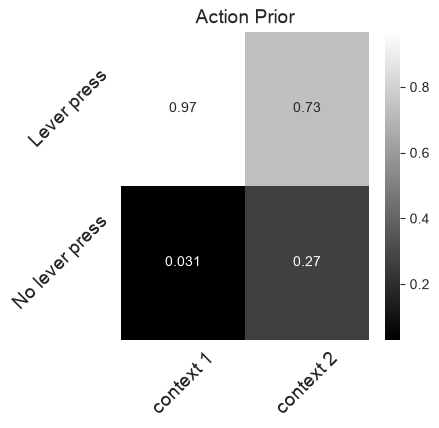

In [46]:
# %matplotlib widget
import matplotlib.pyplot as plt
from scipy import stats

# import ipywidget/s
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.nc = nc
		self.ns = env.ns
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.na = na
		self.nc = nc
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])



		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context_sarah(self,t,tau, likelihood_policies, posterior_policies, prior_context):
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t]

			posterior_context = (posterior_policies * self.ln(likelihood_policies)).sum(axis=0) \
								- (posterior_policies * self.ln(posterior_policies)).sum(axis=0)\
								+ (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0))\
								+ self.ln(prior_context)                            
		else:
			posterior_context = self.ln(prior_context)

		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		self.posterior_context[tau,t] = posterior_context


		return posterior_context
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau+1,t,:,:,k].round(3))


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				#  state_mapping = {"lever_press":0, "no_lever_press":1, "magazine_empty":3, "magazine_full_О1":4, "magazine_full_О2":5, "initial_state":6},
				 reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
				 action_mapping = {"lever_press":0, "no_lever_press":1},
				 rho_noncontingent = 0.0):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)
		self.rho_noncontingent = rho_noncontingent
		self.reward_mapping = reward_mapping
		self.action_mapping = action_mapping
		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol
	

	def sample_reward(self, t, tau, state):

		reward = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		
		if t == 0:
			# distribute initial state reward
			self.rewards[tau,t] = reward
		else:
			regime = self.training_protocol[tau]
			if regime == 0:
				noncontingent_reinforcement = np.random.uniform() <= self.rho_noncontingent
				if noncontingent_reinforcement:
					# print(self.reward_mapping["outcome_2"])
					reward = self.reward_mapping["outcome_2"]


		self.rewards[tau,t] = reward

		return self.rewards[tau,t]
		

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():

	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr

	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]

	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			if tau == 21:
				a = 0
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				#    nb=2, 
				#    ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, 
				   habit_exception=None,
				   rho_noncontingent = 0.0,
				   reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
				   action_mapping = {"lever_press":0, "no_lever_press":1},):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = na - 1
	ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*na + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(na+1)]*(na+1)).transpose([1,0,2])[:,:,:na]

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns,
						rho_noncontingent = rho_noncontingent,
						reward_mapping = reward_mapping,
						action_mapping = action_mapping)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()
	
	# state_trans_matrix = world.agent.state_transition_matrix[:,:,-1,0]
	prior_rewards_matrix = world.agent.prior_rewards[-1,-1,:,:,:]
	policy_prior_matrix = world.agent.prior_policies[-1,-1,:,:]

	return world, prior_rewards_matrix, policy_prior_matrix


def create_dataframe(TAU,T,agent):

			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(2)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(agent.npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()


		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			"context_a": np.array([context_params[0]]*(TAU*T)),
			"context_b": np.array([context_params[1]]*(TAU*T)),
			"context_c": np.array([context_params[2]]*(TAU*T)),
			"context_d": np.array([context_params[3]]*(TAU*T)),
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)

np.random.seed(1)
for seed in np.random.randint(1, 1000000 + 1, size=1):
	reps = 30
	n_blocks_train = 10
	n_blocks_extinction = 1
	block_length = 30

	n_train = n_blocks_train*block_length
	n_extinction = n_blocks_extinction*block_length
	TAU = n_train + n_extinction
	T = 2
	nr = 4
	na = 2
	ns = na+1
	nc = 2
	reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3}
	action_mapping = {"lever_press":0, "no_lever_press":1}

	### Working!
	context_volatility=0.99
	h=10
	habit_exception = 1
	r = 0.05
	p = 0.45
	utility_1 = [[0.45,0.45, 0.1], [p, r, 1-p-r]]
	utility_2 = [[0.45,0.45, 0.1], [r, p, 1-p-r]]
	rho_noncontingent = 0.2
	rho = 0.8
	Rho = np.stack([[[  rho, 0.0, 0.0],
					[  0.0, 0.0, 0.0],
					[1-rho, 1.0, 0.0],
					[  0.0, 0.0, 1.0]],
					[[0, 0, 0],
					[0, 0, 0],
					[1, 1, 0],
					[0, 0, 1]]], axis=-1)



	long_dfs = []

	sim = 0
	srm = np.zeros([nr,ns,nc,reps*2])
	pcm = np.zeros([na,nc,reps*2])
	for rep in range(reps):
		for group, util in enumerate([utility_1,utility_2]):

			world, srm[:,:,:,sim], pcm[:,:,sim] = run_simulation(debug=False,
														utility=util,
														na=2,
														T=T,
														n_train=n_train,
														n_extinction=n_extinction,
														Rho=Rho,
														context_volatility=context_volatility,
														h=h,
														habit_exception = habit_exception,
														rho_noncontingent = rho_noncontingent,
														reward_mapping = reward_mapping,
														action_mapping = action_mapping)

			training_protocol = world.environment.training_protocol
			agent = world.agent

			
			# Create long format dataframe
			run_arr = np.full(TAU * T, rep)
			tau_arr = np.repeat(np.arange(TAU), T)
			t_arr = np.tile(np.arange(T), TAU)
			observation_arr = world.environment.observations.flatten()
			# reward_arr = world.environment.rewards.flatten()
			reward_arr = world.environment.rewards[:,-1].repeat(2)

			action_arr = np.full((TAU,T), np.nan) 
			action_arr[:,0] = world.environment.actions[:,0]
			action_arr = action_arr.flatten()
			h_arr = np.full(TAU * T, agent.h)
			context_volatility_arr = np.full(TAU * T, agent.context_volatility)
			experimental_group_arr = np.full(TAU * T, group)
			sim_arr = np.full(TAU*T,sim)
			true_context = np.array(training_protocol).repeat(2)
			block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
			# Policy arrays
			prior_arr = {}
			likelihood_arr = {}
			posterior_arr = {}
			context_post_arr = {}
			policy_ent_arr = {}
			policy_surpr_arr = {}
			ourcome_surpr_arr = {}
			policy_post_arr = {}
			reward_prior_arr = {}

			for c in range(agent.nc):
				context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
				policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
				policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
				ourcome_surpr_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
				
				for pi in range(agent.npi):
					reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
					prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
					likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
					posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
			
			action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
			
			for pi in range(agent.npi):
				policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()
		
			### calculate H
			sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
			exponential = lambda t, b, c, d: d + np.exp(b*(t-c))
			
			fitting_functions = [sigmoid, exponential]
			t = np.arange(1,TAU+1)

			q_context = agent.posterior_context[:,1,1]
			q_action =  np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0])[:,1]
			switch = n_blocks_train*block_length + block_length//2

			try:
				context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,switch,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)
				context_func = 0.


			except RuntimeError:

				try:
					context_pcov = np.eye(4)
					context_params = np.zeros(4)
					context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
					context_params[0] = 1
					context_func = 1

				except RuntimeError:
					context_params[:] = np.nan
					context_func = np.nan

			try:
				# posterior_pol = (w.agent.posterior_policies[:,0,1]*w.agent.posterior_context[:,0]).sum(axis=1)[10:]
				# plt.figure()
				# plt.ylim((0,1))


				policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
				policy_func = 0

			except RuntimeError:

				try:
					policy_params = np.zeros(4)
					policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
					policy_params[0] = 1.
					policy_func = 1


				except RuntimeError:
					policy_params[:] = np.nan
					policy_func = np.nan


			# Create dict
			long_df_dict = {
				"run": run_arr,
				"tau": tau_arr,
				"t": t_arr,
				"observation": observation_arr,
				"action": action_arr,
				"reward": reward_arr,
				"h": h_arr,
				"context_volatility": context_volatility_arr,
				"experimental_group": experimental_group_arr,
				"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
				"sim":sim_arr,
				"true_context":true_context,
				"block":block_arr,
				"context_a": np.array([context_params[0]]*(TAU*T)),
				"context_b": np.array([context_params[1]]*(TAU*T)),
				"context_c": np.array([context_params[2]]*(TAU*T)),
				"context_d": np.array([context_params[3]]*(TAU*T)),
				**prior_arr,
				**likelihood_arr,
				**posterior_arr,
				**context_post_arr,
				**policy_ent_arr,
				**policy_surpr_arr,
				**ourcome_surpr_arr,
				**policy_post_arr,
				**reward_prior_arr
			}

			long_df = pd.DataFrame(long_df_dict)
			long_dfs.append(long_df)

			sim += 1


	dataframe = pd.concat(long_dfs)
	matrices = {"reward_generation_matrix": srm.mean(axis=-1), "policy_prior_matrix": pcm.mean(axis=-1)}


	l = {"action_legend_labels":["Lever press", "No lever press"],
		"state_legend_labels":["Lever press", "No lever press","init state"],
		"reward_legend_labels":["O1","O2","no reward", "init state reward"]}

	# fig, axes = plt.subplots(1,3,figsize=(12,3))

	# g = sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
	# # g = sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")
	# g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45)
	# g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45)

	# g = sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[1])
	# g.yaxis.set_ticklabels(l["reward_legend_labels"][:-1],rotation=45)
	# g.set_xlabel("trial")

	# g = sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[2])
	# g.yaxis.set_ticklabels(l["reward_legend_labels"][:-1],rotation=45)
	# g.set_xlabel("trial")
	# # g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45)
	# for ax, title in zip(axes, ["p(reward|state) Training", "Utility Group 1", "Utility Group 2"]): # ,"p(reward|state) Degradation", "Block Type"
	# 	ax.set_title(title)



	""" Context Mixing / Effect size correlation """
	df = dataframe.copy()
	df["context_c"] = df["context_c"] - n_blocks_train*block_length
	df = df.groupby(by=["experimental_group","sim","phase","t","context_c"])[["action"]].value_counts(normalize=True)
	df = ((df[:,:,"extinction",0,:])/(df[:,:,"training",0,:])).reset_index().query("action == 0")
	df.loc[(df["context_c"] > block_length) | (df["context_c"] < 0),"context_c"] = np.nan


	d = df[["experimental_group", "proportion","context_c"]].dropna()
	plt.figure()
	plt.subplot(1,1,1)
	r_g1,p_g1 = pearsonr(d.query("experimental_group==0")["context_c"], d.query("experimental_group==0")["proportion"])
	r_g2,p_g2 = pearsonr(d.query("experimental_group==1")["context_c"], d.query("experimental_group==1")["proportion"])

	p = 0.05
	p_g1 = p if p_g1 < p else p_g1
	p_g2 = p if p_g2 < p else p_g2

	g = sns.regplot(data=df.query("experimental_group==0"), x="proportion",y="context_c", ci=95, scatter_kws={"alpha":0.5},label=fr"O2 devalued Pearson $\rho$: {r_g1.round(2)}, p<{p_g1}")
	g = sns.regplot(data=df.query("experimental_group==1"), x="proportion",y="context_c", ci=95, scatter_kws={"alpha":0.5},label=fr"O1 devalued Pearson $\rho$: {r_g2.round(2)}, p<{p_g2}")
	g.legend()
	g.set_ylabel("Extinction trial when novel\n context inferred with $q(c)>0.5$", fontsize=14)
	g.set_xlabel("Relative lever press (training/extinction)", fontsize=14)


	""" Relative action counts in EXTINCTION """
	df = dataframe.groupby(by=["experimental_group","sim","phase","t"])["action"].value_counts()
	df_counts =  df.groupby(by=["experimental_group", "sim","phase","t"]).sum()
	df = df/df_counts
	relative_action = (df[:,:,"extinction",0])/(df[:,:,"training",0])
	plt.figure()
	g = sns.barplot(data=relative_action.reset_index().astype({"experimental_group":"category"}).query("action == 0"),
					x="experimental_group", y="count", edgecolor="black",linewidth=0.5,palette=["white", "black"])
	g.xaxis.set_ticklabels(["O2 devalued \n (noncontingent)", "O1 devalued \n (contingent)"],rotation=0, fontsize=14)
	g.set_ylabel("Relative lever press (training/extinction)", fontsize=14)
	g.set_xlabel("Experimental Group", fontsize=14)
	g.set_ylim((0,1.2))
	# Statistics
	x = relative_action.reset_index().query("action == 0")

	g1, g2 = [x.loc[x.experimental_group == g, "count"].dropna()
			for g in x.experimental_group.unique()]

	# Shapiro-Wilk normality tests
	normal = all(stats.shapiro(g)[1] > .05 for g in [g1, g2])

	if normal:
		stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)  # Welch's t-test
		title = f"Welch's t-test: t = {stat:.3f}, p_val = {p_val:.4f}"
	else:
		stat, p_val = stats.mannwhitneyu(g1, g2, alternative="two-sided")
		title = f"Mann-Whitney U: U = {stat:.3f}, p_val = {p_val:.4f}"

	plt.title(title, fontsize=14)

	""" Action frequency in each experimental block"""
	df = (dataframe.groupby(by=["experimental_group","sim","block","t"])["action"].value_counts()).reset_index()
	plt.figure(figsize=(7,3))

	plt.subplot(1,2,1)
	plt.title("Group where noncontingent\n O2 devalued", fontsize=14)
	g = sns.pointplot(data=df.astype({"experimental_group":"category"}).query("experimental_group==0"), x="block",y="count",hue="action")
	g.set_ylabel("Action count", fontsize=14)
	g.legend(handles=g.get_legend_handles_labels()[0], labels=l["action_legend_labels"], fontsize=14)

	plt.subplot(1,2,2)
	g = sns.pointplot(data=df.query("experimental_group==1"), x="block",y="count",hue="action")
	g.set_ylabel("Action count", fontsize=14)
	g.legend(handles=g.get_legend_handles_labels()[0], labels=l["action_legend_labels"], fontsize=14)
	plt.title("Group where contingent\n O1 devalued", fontsize=14)

	plt.subplots_adjust(wspace=0.3)


	""" Context posterior """
	plt.figure(figsize=(7,3))
	plt.subplot(1,2,1)
	sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
	g.set_ylabel("Context posterior", fontsize=14)
	plt.title("Group where noncontingent\n O2 devalued", fontsize=14)

	plt.subplot(1,2,2)
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
	g.set_ylabel("Context posterior", fontsize=14)
	plt.title("Group where contingent\n O1 devalued", fontsize=14)

	plt.subplots_adjust(wspace=0.3)


	""" Learned reward contingencies"""
	plt.figure(figsize=(11,4))
	plt.subplot(1,2,1)
	g = sns.heatmap(matrices["reward_generation_matrix"][:,:,0],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45, fontsize=14,)
	plt.subplot(1,2,2)
	g = sns.heatmap(matrices["reward_generation_matrix"][:,:,1],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45, fontsize=14)


	""" Learned policy prior"""
	plt.figure(figsize=(4,4))
	plt.subplot(1,1,1)
	plt.title("Action Prior", fontsize=14)
	g = sns.heatmap(matrices["policy_prior_matrix"],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["action_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(["context 1", "context 2"],rotation=45, fontsize=14)
	# plt.subplot(1,2,2)
	# sns.heatmap(agent.prior_policies_counts[-1,-1,:,1],annot=True)

	# """Reinforcement schedule"""

	# plt.figure()
	# df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
	# sns.barplot(data = df.query("phase == 'training' & t == 1"), y="count",hue="reward")



## Two-lever

/tmp/ipykernel_79363/2202558043.py:783: DeprecationWarning: This function is deprecated. Please call randint(1, 1000000 + 1) instead
  for seed in np.random.random_integers(1000000, size=1):
/tmp/ipykernel_79363/2202558043.py:938: OptimizeWarning: Covariance of the parameters could not be estimated
  policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
/tmp/ipykernel_79363/2202558043.py:1040: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(data=relative_action.reset_index().astype({"experimental_group":"category"}).query("action == 0"),
/tmp/ipykernel_79363/2202558043.py:1044: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels([

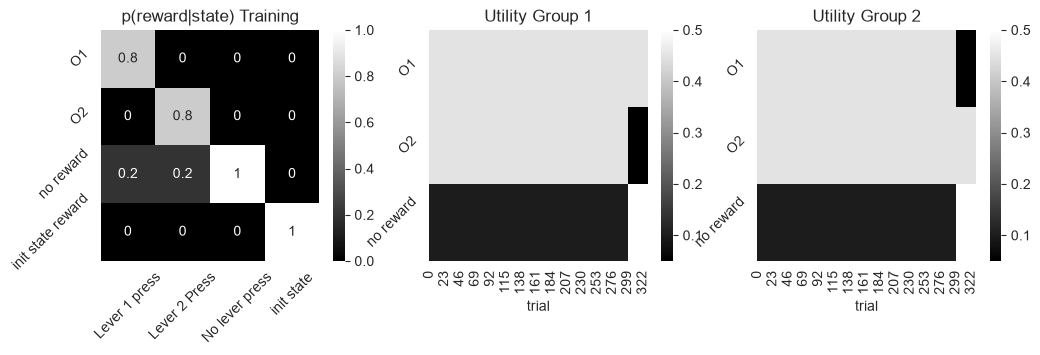

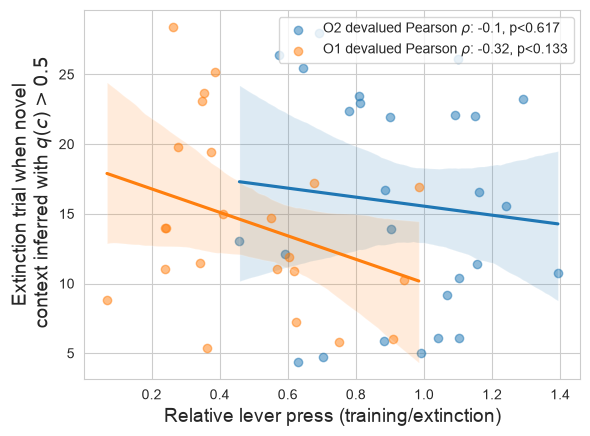

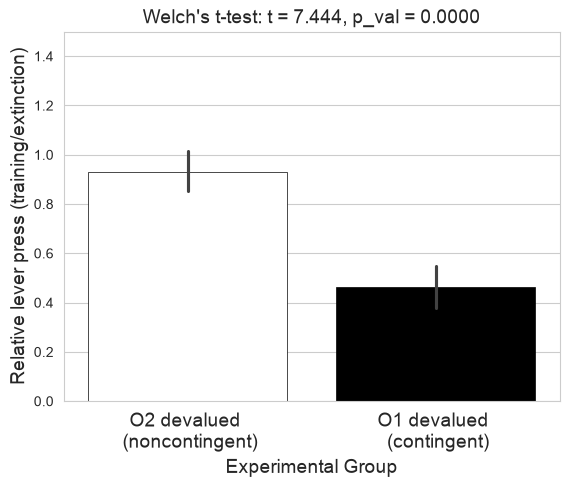

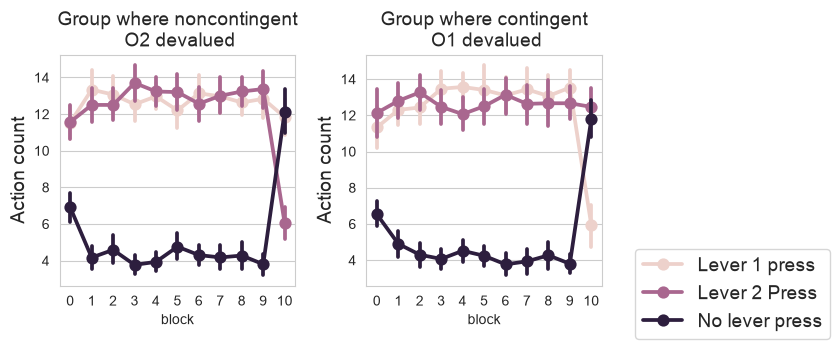

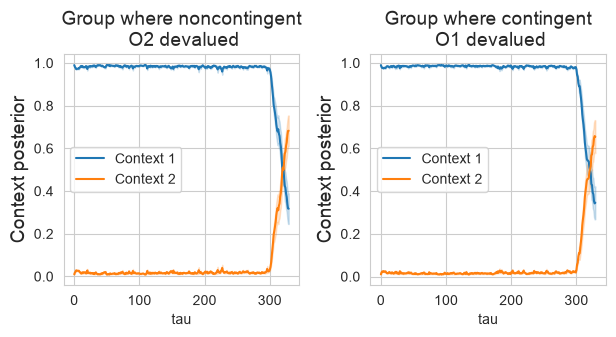

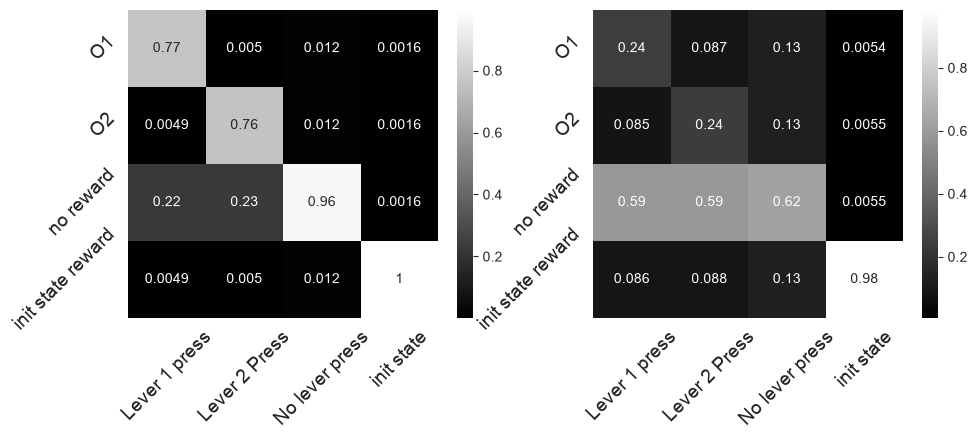

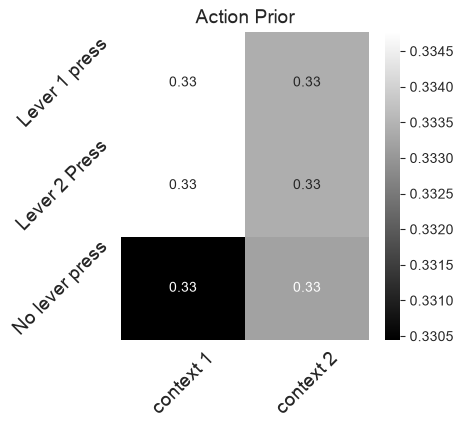

In [2]:
# %matplotlib widget
import matplotlib.pyplot as plt
from scipy import stats

# import ipywidget/s
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')


class Agent():

	def __init__(self,
				 state_transition_matrix,            # p(s_t|s_t-1)
				 utility,                            # pre-given desirability of observations
				 policies,                           # all possible policies given environment setup
				 prior_rewards,                      # p(s_t|s_t-1)
				 counts_prior_rewards,               # parameters beta of p(phi|beta)
				 prior_policies,                     # p(pi|theta)
				 counts_prior_policies,              # parameters alpha of p(theta|alpha)
				 prior_states,                       # initial p(s|c)
				 prior_context,                      # initial p(c)
				 na,
				 nc,
				 env,
				 approx_pred_pol = True,             # use digamma approx when updating policy prior p(pi|c)
				 approx_pred_rew = True,             # use digamma approx when updating reward posterir p(r|s,c)
				 observation_generation_matrix=None, # p(o_t|s_t)
				 dec_temp = 1,
				 debug=False,
				 context_transition_matrix=None,
				 habit_exception = None
				):
		
		self.na = na
		self.nc = nc

		self.environment = env
		self.TAU = env.TAU
		self.T = env.T
		self.nr = env.nr
		self.ns = env.ns
		# print(self.ns)
		self.npi = policies.shape[0]
		self.actions = env.actions
		self.rewards = env.rewards
		self.observations = env.observations
		self.habit_exception=habit_exception

		self.state_transition_matrix = state_transition_matrix
		self.context_transition_matrix = context_transition_matrix
		self.utility = utility

		if len(utility.shape) > 1:
			self.changing_preference = True
		else:
			self.changing_preference = False                                        
		
		self.policies = policies
		self.prior_states = prior_states                           
		self.approx_pred_pol = approx_pred_pol
		self.approx_pred_rew = approx_pred_rew
		self.dec_temp = dec_temp
		
		self.possible_policies = self.policies.copy()
		self.possible_policies_ind = np.arange(self.policies.shape[0])                                 

		self.debug = debug

		# belief update logs
		self.posterior_states = np.zeros([self.TAU,self.T, self.ns, self.T, self.npi, self.nc])

		self.prior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies[0,:] = prior_policies

		self.prior_policies_counts = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.prior_policies_counts[0,:] = counts_prior_policies[None,:,:]
		
		self.prior_rewards = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards[0,:] = prior_rewards[None,:,:,:]

		self.posterior_predictive_rewards = prior_rewards.copy()

		self.prior_rewards_counts = np.zeros([self.TAU, self.T, self.nr, self.ns, self.nc])
		self.prior_rewards_counts[0,0] = counts_prior_rewards

		self.dir_rew_params = counts_prior_rewards.copy()

		self.forward_norms = np.zeros([self.TAU, self.T, self.T+1, self.npi, self.nc])
		self.likelihood_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		self.posterior_policies = np.zeros([self.TAU, self.T, self.npi, self.nc])
		
		self.prior_context = np.zeros([self.TAU, self.T, self.nc])
		self.prior_context[0,:] = prior_context[None,:]
		self.posterior_context = np.zeros([self.TAU, self.T, self.nc])
		self.policy_entropy = np.zeros([self.TAU, self.T, self.nc])
		self.outcome_surprise = np.zeros([self.TAU, self.T, self.nc])
		self.policy_surprise = np.zeros([self.TAU, self.T, self.nc])



		self.observation_generation_matrix = observation_generation_matrix


	def ln(self, array):
		# array[array==0] = 1e-20
		return np.nan_to_num(np.log(array))


	def linear_ind(self, array):
		
		array = array[:,None].T if array.shape[-1] == 1 else array.T
		return np.ravel_multi_index(array, [self.na]*(self.T-1))


	def digamma_approximation(self, counts):
		return scp.softmax(scp.digamma(counts) - scp.digamma(counts.sum(axis=0)),axis=0)
	
								
	def initialize_states_messages(self,t,tau):

		# initialize messages for Bethe Approximation Belief Propagation

		self.fwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.fwd_messages[:,0,:,:] = self.prior_states[:,None,None]

		self.fwd_norms = np.zeros([self.T+1, self.npi, self.nc])
		self.fwd_norms[0,:,:] = 1                               # accounts for the normalizing constant of the prior

		self.bwd_messages = np.zeros([self.ns, self.T, self.npi, self.nc]) + 1/self.ns
		self.bwd_norms = np.zeros([self.T, self.npi, self.nc])

		self.obs_messages = np.zeros((self.ns, self.T, self.npi, self.nc)) + 1/self.ns

		self.reward_messages = np.zeros([self.ns, self.T, self.npi, self.nc])

		if self.changing_preference:
			util = self.utility[tau]
		else:
			util = self.utility


		rew_mess = np.einsum('r,rsc -> sc', util, self.posterior_predictive_rewards)
		# rew_mess /= rew_mess.sum(axis=0)

		self.reward_messages[:] = rew_mess[:,None,None,:]

		# backward message intialization
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				for t, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
					self.bwd_messages[:,t,pi,c] = (self.bwd_messages[:,t+1,pi,c]*self.obs_messages[:,t+1,pi,c]*self.reward_messages[:,t+1,pi,c])\
												   .dot(self.state_transition_matrix[:,:,u])
												  
					self.bwd_norms[t,pi,c] = self.bwd_messages[:,t,pi,c].sum()
					self.bwd_messages[:,t,pi,c] /= self.bwd_norms[t,pi,c] 
		

	def update_states_messages(self,t,tau,pi,policy,c,reward,observation):
		
		# update rewards messages based on what was observed
		self.reward_messages[:,t,:,:] = self.posterior_predictive_rewards[reward,:,None,:]

		self.obs_messages[:,t,:,:] = self.observation_generation_matrix[observation,:,None,None]
		
		# perform forward pass
		if (t < self.T-1):
			for tp, u in enumerate(policy):
				self.fwd_messages[:,tp+1,pi,c] = self.state_transition_matrix[:,:,u]\
												 .dot(self.fwd_messages[:,tp,pi,c]*self.obs_messages[:,tp,pi,c]*self.reward_messages[:,tp,pi,c])
				self.fwd_norms[tp+1,pi,c] = self.fwd_messages[:,tp+1,pi,c].sum() 
				self.fwd_messages[:,tp+1,pi,c] /= self.fwd_norms[tp+1,pi,c]

		# update backward pass based on observed information
		if(t>0):
			for tp, u in zip(np.flip(np.arange(self.T-1)), np.flip(policy)):
				self.bwd_messages[:,tp,pi,c] = (self.bwd_messages[:,tp+1,pi,c]*self.obs_messages[:,tp+1,pi,c]*self.reward_messages[:,tp+1,pi,c])\
												.dot(self.state_transition_matrix[:,:,u])
				self.bwd_messages[:,tp,pi,c] /= self.bwd_messages[:,tp,pi,c].sum() 


	def update_beliefs_states(self, t, tau, reward, action, observation):
		if tau == 1:
			pass
		if t==0:
			self.possible_policies = self.policies.copy()
			self.possible_policies_ind = np.arange(self.policies.shape[0])
			self.initialize_states_messages(t,tau)
		
		# check which policies are still possible
		if action is not None:
			self.possible_policies = self.possible_policies[self.possible_policies[:,t-1] == action]
			self.possible_policies_ind = self.linear_ind(self.possible_policies)
			
		for c in range(self.nc):
			for pi, policy in enumerate(self.policies):
				if pi in self.possible_policies_ind:
					# for tp, u in enumerate(policy):
					self.update_states_messages(t,tau,pi,policy,c,reward,observation)
				else:
					self.fwd_messages[:,:,pi,:] = 0
					self.fwd_norms[:,pi,:] = 0

		post  = self.fwd_messages*self.bwd_messages*self.obs_messages*self.reward_messages
		post_norm = post.sum(axis=0)
		post = np.nan_to_num(post/post_norm)

		self.fwd_norms[-1,:,:] = post_norm[-1,:,:]
		self.forward_norms[tau,t] = self.fwd_norms
		self.posterior_states[tau,t,:,:,:,:] = post

		return post
	

	def update_beliefs_policies(self,t,tau):
		
		likelihood = self.fwd_norms.prod(axis=0)                      # exp(log(norms)) = -F(pi,c) 
		posterior_policies  = np.power(likelihood, self.dec_temp) * self.prior_policies[tau,t]   # exp(digamma(alpha_ij) - digamma(alpha_j)) when you integrate theta out
		posterior_policies /= posterior_policies.sum(axis=0)
		
		# store in global log
		self.likelihood_policies[tau,t] = likelihood/likelihood.sum(axis=0)
		self.posterior_policies[tau,t] = posterior_policies


		return likelihood, posterior_policies
	

	def update_beliefs_context_sarah(self,t,tau, likelihood_policies, posterior_policies, prior_context):
		
		if t>0:
			alphas = self.prior_policies_counts[tau,t]

			posterior_context = (posterior_policies * self.ln(likelihood_policies)).sum(axis=0) \
								- (posterior_policies * self.ln(posterior_policies)).sum(axis=0)\
								+ (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0))\
								+ self.ln(prior_context)                            
		else:
			posterior_context = self.ln(prior_context)

		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		self.posterior_context[tau,t] = posterior_context


		return posterior_context
	

	def update_beliefs_context(self,t,tau, likelihood_policies, posterior_policies, prior_context):
	
		# print(tau,t)
		# context-specific policy likelihood
		if t>0:
			alphas = self.prior_policies_counts[tau,t].copy()
			chosen_pol = np.argmax(posterior_policies[:,0])
			alpha_prime = alphas.copy()
			alpha_prime[chosen_pol,:] += prior_context
			outcome_surprise =   (posterior_policies * self.ln(likelihood_policies)).sum(axis=0)
			policy_entropy   =  -(posterior_policies * self.ln(posterior_policies)).sum(axis=0)
			policy_surprise  =   (posterior_policies * (scp.digamma(alpha_prime) - scp.digamma(alpha_prime.sum(axis=0)))).sum(axis=0)# (posterior_policies * scp.digamma(alphas)).sum(axis=0) - scp.digamma(alphas.sum(axis=0)) #


			# print('\n',tau, self.rewards[tau,t], self.actions[tau][0])
			# print('outcome_surprise')
			# print(outcome_surprise.round(3))
			# print('policy_entropy')
			# print(policy_entropy.round(3))
			# print('policy_surprise')
			# print(policy_surprise.round(3))
			# print('prior_context')
			# print(self.ln(prior_context).round(3))
			# print('posterior context')
			# print(np.nan_to_num(scp.softmax(posterior_context)))
		else:
			outcome_surprise = 0
			policy_entropy   = 0
			policy_surprise  = 0

		posterior_context = outcome_surprise + policy_entropy + policy_surprise + self.ln(prior_context)
		posterior_context = np.nan_to_num(scp.softmax(posterior_context))
		# print(posterior_context)
		self.posterior_context[tau,t] = posterior_context
		self.policy_surprise[tau,t] = policy_surprise
		self.policy_entropy[tau,t] = policy_entropy
		self.outcome_surprise[tau,t] = outcome_surprise
		
		return posterior_context
	

	def update_beliefs_prior_rewards(self,t,tau,reward,posterior_states, posterior_policies, posterior_context):
		
		post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		state = np.argmax(post_state,axis=0)

		beta = self.dir_rew_params.copy()
		beta_prime = beta.copy()
		beta_prime[reward,state,:] += posterior_context

		self.prior_rewards_counts[tau,t] = beta_prime

		if self.approx_pred_rew:
			posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		else:
			posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		self.prior_rewards[tau,t] = posterior_predictive_rewards

		return posterior_predictive_rewards, beta_prime

		# post_state = np.einsum('spc,pc->sc', posterior_states[:,t,:,:], posterior_policies)
		# state = np.argmax(post_state,axis=0)

		# beta = self.prior_rewards_counts[tau,t-1]
		# beta_prime = beta.copy()
		# beta_prime[reward,state,:] += posterior_context

		# self.prior_rewards_counts[tau,t] = beta_prime

		# if self.approx_pred_rew:
		#     posterior_predictive_rewards = self.digamma_approximation(beta_prime)
		# else:
		#     posterior_predictive_rewards = beta_prime / beta_prime.sum(axis=0) 

		# if tau != self.TAU-1:
		#     if t == self.T-1:
		#         self.prior_rewards[tau+1,:2] = posterior_predictive_rewards
		#         self.prior_rewards_counts[tau+1,0] =  beta_prime
		#     else:
		#         self.prior_rewards[tau,t+1] = posterior_predictive_rewards

		# return posterior_predictive_rewards


	def update_beliefs_prior_policies(self,t,tau, posterior_context):
		
		pol_ind = self.linear_ind(self.actions[tau])[0]
		alphas = self.prior_policies_counts[tau,t].copy()
		alphas_prime = alphas.copy()

		if pol_ind != self.habit_exception: 
			alphas_prime[pol_ind,:] += posterior_context
			
		self.prior_policies_counts[tau+1] = alphas_prime[None,:,:]

		if self.approx_pred_pol:
			posterior_predictive_policies = self.digamma_approximation(alphas_prime)
		else:
			posterior_predictive_policies = alphas_prime / alphas_prime.sum(axis=0)
		

		self.prior_policies[tau+1] = posterior_predictive_policies[None,:,:]
		
		# print('\n',tau, ', action: ', self.actions[tau][0])
		# print(posterior_context)
		# print(alphas_prime)
		# print(posterior_predictive_policies)


	def update_beliefs(self, t, tau, state, reward, action, observation):
		
		posterior_states = self.update_beliefs_states(t, tau, reward, action, observation)
		
		likelihood_policies, posterior_policies = self.update_beliefs_policies(t,tau)


		if t == 0 and tau != 0:
			prior_context = self.posterior_context[tau-1,-1]
			self.prior_context[tau] = self.context_transition_matrix.dot(prior_context)
			# in future add here context transition matrix

		prior_context = self.prior_context[tau,t]
		posterior_context = self.update_beliefs_context(t,tau, likelihood_policies, posterior_policies, prior_context)


		self.posterior_predictive_rewards, self.dir_rew_params = self.update_beliefs_prior_rewards(t,tau,reward, posterior_states,
																		posterior_policies,posterior_context)

		if (t == self.T-1 and tau < self.TAU-1):
			self.update_beliefs_prior_policies(t, tau, posterior_context)
			
		if tau < self.TAU - 1 and self.debug:
			print(f"--------------------\ntau,t: {tau,t}")
			print(f"action: {action}, observation: {observation}, reward: {reward}")


			print(f"\nq(R|pi,c); policy likelihood:")
			print(likelihood_policies.round(3))

			print(f"q(pi|c) policy posterior:")
			print(posterior_policies.round(3))
			
			print(f"\nposterior_context:")
			print(posterior_context.round(3))


			if t == self.T-1:

				print(f"\nrewards counts:")
				print(f"obs, reward: {observation, reward}")
				for k in range(self.nc):
					print(f"\n{self.prior_rewards_counts[tau,t,:,:,k].round(3)}")
				
				print(f"prior_rewards")
				for k in range(self.nc):
					print(self.prior_rewards[tau+1,t,:,:,k].round(3))


	def sample_action(self,t,tau):

		post_policies = self.posterior_policies[tau,t]
		post_context = self.posterior_context[tau,t]

		post_policies = post_policies.dot(post_context)
		# chosen_action = self.policies[np.argmax(post_policies)][t]
		
		post_actions = np.zeros(self.na)
		for a in range(self.na):
			post_actions[a] = post_policies[self.policies[:,t] == a].sum()

		chosen_action = np.random.choice(np.arange(self.na), p=post_actions)
		self.actions[tau,t] = chosen_action
		
		return chosen_action


class MultiArmedBandit():

	def __init__(self,
				 state_transition_matrix,
				 reward_generation_matrix,
				 training_protocol=None,
				 TAU=3,
				 T=2,
				 n_bandits=2,
				 observation_generation_matrix=None, no=None,
				#  state_mapping = {"lever_press":0, "no_lever_press":1, "magazine_empty":3, "magazine_full_О1":4, "magazine_full_О2":5, "initial_state":6},
				 reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
				 action_mapping = {"lever_press":0, "no_lever_press":1},
				 rho_noncontingent = 0.0):

		self.Rho = reward_generation_matrix
		self.B = state_transition_matrix
		self.nr, self.ns, self.TAU = reward_generation_matrix.shape
		self.na =  self.B.shape[-1]
		self.states  = np.zeros([TAU,T],dtype=int)
		self.rewards = np.zeros([TAU,T],dtype=int)
		self.actions = np.zeros([TAU, T-1],dtype=int)
		self.observations = np.zeros([TAU,T],dtype=int)
		self.rho_noncontingent = rho_noncontingent
		self.reward_mapping = reward_mapping
		self.action_mapping = action_mapping
		self.TAU = TAU
		self.T = T
		self.nb = n_bandits

		if observation_generation_matrix is None:
			self.observation_generation_matrix = np.eye(self.ns)
			self.no = self.ns.copy()
		else:
			self.observation_generation_matrix = observation_generation_matrix
			self.no = no

		self.training_protocol = training_protocol
	

	def sample_reward(self, t, tau, state):

		reward = np.random.choice(np.arange(self.nr), p=self.Rho[:,state,tau])
		
		if t == 0:
			# distribute initial state reward
			self.rewards[tau,t] = reward
		else:
			regime = self.training_protocol[tau]
			if regime == 0:
				noncontingent_reinforcement = np.random.uniform() <= self.rho_noncontingent
				if noncontingent_reinforcement:
					# print(self.reward_mapping["outcome_2"])
					reward = self.reward_mapping["outcome_2"]


		self.rewards[tau,t] = reward

		return self.rewards[tau,t]
		

	def sample_hidden_state(self, t, tau, action):
		self.actions[tau,t-1] = action
		self.states[tau,t] = np.random.choice(np.arange(self.ns), p=self.B[:,self.states[tau, t-1], action])
		
		return self.states[tau,t]
	
	
	def generate_observation(self, t, tau, state):

		self.observations[tau,t] = np.random.choice(np.arange(self.no), p=self.observation_generation_matrix[:,state])
		return self.observations[tau,t]
	

	def initialize_hidden_state(self, tau, starting_state=2):
		self.states[tau,0] = starting_state
		return starting_state


class World():

	def __init__(self, agent, environment,training_protocol=None):

		self.environment = environment
		self.agent = agent
		# self.perc - self.agent.perc
		self.TAU = environment.TAU
		self.T = environment.T
		self.nr = environment.nr

	def simulate_belief_update(self, actions, rewards, observations):

		for tau in range(self.TAU):
			for t in range(self.T):
				if t == 0:
					action=None
					state = observations[tau,t]
				else:
					state = observations[tau,t]

				observation = observations[tau,t]

				reward = rewards[tau,t]
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = actions[tau,0]

	def simulate_experiment(self, TAU=None):

		for tau in range(self.TAU):
			if tau == 21:
				a = 0
			for t in range(self.T):
				if t == 0:
					action=None
					state = self.environment.initialize_hidden_state(tau, starting_state=self.environment.nb)
				else:
					state = self.environment.sample_hidden_state(t, tau, action)

				observation = self.environment.generate_observation(t,tau,state)

				reward = self.environment.sample_reward(t, tau, state)
				
				self.agent.update_beliefs(t, tau, state, reward, action, observation)

				if t < self.T-1:
					action = self.agent.sample_action(t,tau)

				# if t == self.T-1:
				#     perc = self.agent.perc
				#     for c in range(perc.k):
				#         print(f"\n\ntrial: {tau}, t: {t}, context: {c}")
				#         print(f"action: {action}, reward: {reward}")
				#         print(f"\npost_states:\n{perc.posterior_states[tau,t,:,:,action,c]}")
				#         print(f"\nprior_context:\n{perc.prior_context[tau,t].round(3)}")
				#         print(f"\nposterior_context:\n{perc.posterior_context[tau,t].round(3)}")
				#         print(f"\nprior_rewards:\n{perc.prior_rewards_counts[tau+1,t,:,:,c].round(3)}")
				#         print(f"\nprior_policies:\n{perc.prior_policies_counts[tau+1,t,:,c].round(3)}")
				
				#     if tau==103:
				#         a=0


def run_simulation(h=1000, 
				   n_train = 20,
				   n_extinction = 5, 
				#    rep=1, 
				   na=3, 
				#    nb=2, 
				#    ns=3, 
				#    no=3, 
				   nr=4, 
				   nc=2, 
				   T=2, 
				   approx_pred_pol = True, 
				   approx_pred_rew = True,
				   utility = [[0.45,0.45, 0.01], [0.8, 0.1, 0.1]], #[[0.45,0.45, 0.01], [0.1,0.8, 0.1]],
				   Rho = None, 
				   debug=False, 
				   context_volatility=0.98, 
				   habit_exception=None,
				   rho_noncontingent = 0.0,
				   reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
				   action_mapping = {"lever_press":0, "no_lever_press":1},):
	
	TAU = n_train + n_extinction

	'''           define policies            '''
	npi = na**(T-1)
	nb = na - 1
	ns = na+1


	# policies = list(product(list(np.arange(na))*(T-1)))
	policies = np.array(list(product( np.arange(na), repeat= T-1)))


	'''       define p(s_t|s_t-1, a_t-1)      '''
	prior_states = np.array([0]*na + [1]) # np.array([0,0,1])
	state_transition_matrix = np.array([np.eye(na+1)]*(na+1)).transpose([1,0,2])[:,:,:na]

	'''          define p(o_t|s_t)            '''
	observation_generation_matrix = np.eye(ns)
	
	'''           define p(r|s,c)             '''
	lambda_H = np.ones([nr,ns])
	lambda_H[-1,-1] = 100
	counts_prior_rewards = np.stack([lambda_H for i in range(nc)],axis=-1)
	counts_prior_rewards += np.random.uniform(low=0,high=0.2, size = counts_prior_rewards.shape)


	prior_rewards = counts_prior_rewards / counts_prior_rewards.sum(axis=0)

	'''              define p(pi|c)           '''
	counts_prior_policies = np.zeros([npi,nc]) + h


	prior_policies = counts_prior_policies / counts_prior_policies.sum(axis=0)


	'''       define prior over contexts p(c) '''
	prior_context = np.array([0.99] + [1-0.99]*(nc-1))

	p = 0.9
	q = 1-p

	'''   p(c_t|c_t-1)'''

	q = (1-context_volatility)/(nc-1)
	context_transition_matrix = np.eye(nc)*(1-nc*q) + q
	assert(np.all(context_transition_matrix.sum(axis=0) == 1))

	'''   define Env reward generation matrix if not passed as argument'''
	training_protocol = [0]*n_train + [1]*n_extinction

	Rho = Rho[:,:,training_protocol]

	utilities =  np.zeros([TAU,nr])
	utilities[:n_train,:-1] = np.array(utility[0])[None, :]
	utilities[n_train:,:-1] = np.array(utility[1])[None, :]

	# Run Simulations
	env = MultiArmedBandit(state_transition_matrix,
						Rho, 
						TAU=TAU,
						T=T,
						n_bandits = na,
						training_protocol=training_protocol,
						observation_generation_matrix=observation_generation_matrix,
						no=ns,
						rho_noncontingent = rho_noncontingent,
						reward_mapping = reward_mapping,
						action_mapping = action_mapping)

	agent = Agent(
			state_transition_matrix,
			utilities,
			policies,
			prior_rewards,
			counts_prior_rewards,
			prior_policies,
			counts_prior_policies,
			prior_states,
			prior_context,
			na,
			nc,
			env,
			approx_pred_pol = approx_pred_pol,
			approx_pred_rew = approx_pred_rew,
			observation_generation_matrix = observation_generation_matrix,
			debug=debug,
			context_transition_matrix = context_transition_matrix,
			habit_exception=habit_exception
			)

	world = World(agent, env)
	world.agent.context_volatility = context_volatility
	world.agent.h = h
	world.simulate_experiment()
	
	# state_trans_matrix = world.agent.state_transition_matrix[:,:,-1,0]
	prior_rewards_matrix = world.agent.prior_rewards[-1,-1,:,:,:]
	policy_prior_matrix = world.agent.prior_policies[-1,-1,:,:]

	return world, prior_rewards_matrix, policy_prior_matrix


def create_dataframe(TAU,T,agent):

			# Create long format dataframe
		run_arr = np.full(TAU * T, rep)
		tau_arr = np.repeat(np.arange(TAU), T)
		t_arr = np.tile(np.arange(T), TAU)
		observation_arr = world.environment.observations.flatten()
		# reward_arr = world.environment.rewards.flatten()
		reward_arr = world.environment.rewards[:,-1].repeat(2)

		action_arr = np.full((TAU,T), np.nan) 
		action_arr[:,0] = world.environment.actions[:,0]
		action_arr = action_arr.flatten()
		h_arr = np.full(TAU * T, agent.h)
		context_volatility_arr = np.full(TAU * T, agent.context_volatility)
		experimental_group_arr = np.full(TAU * T, group)
		sim_arr = np.full(TAU*T,sim)
		true_context = np.array(training_protocol).repeat(2)
		block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
		# Policy arrays
		prior_arr = {}
		likelihood_arr = {}
		posterior_arr = {}
		context_post_arr = {}
		policy_ent_arr = {}
		policy_surpr_arr = {}
		outcome_surprise_arr = {}
		policy_post_arr = {}
		reward_prior_arr = {}

		for c in range(agent.nc):
			context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
			policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
			policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
			outcome_surprise_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
			
			for pi in range(agent.npi):
				reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
				prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
				likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
				posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
		
		action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
		
		for pi in range(agent.npi):
			policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()

		# Create dict
		long_df_dict = {
			"run": run_arr,
			"tau": tau_arr,
			"t": t_arr,
			"observation": observation_arr,
			"action": action_arr,
			"reward": reward_arr,
			"h": h_arr,
			"context_volatility": context_volatility_arr,
			"experimental_group": experimental_group_arr,
			"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
			"sim":sim_arr,
			"true_context":true_context,
			"block":block_arr,
			**prior_arr,
			**likelihood_arr,
			**posterior_arr,
			**context_post_arr,
			**policy_ent_arr,
			**policy_surpr_arr,
			**outcome_surprise_arr,
			**policy_post_arr,
			**reward_prior_arr
		}

		return pd.DataFrame(long_df_dict)

np.random.seed(2)

for seed in np.random.random_integers(1000000, size=1):
	reps = 30
	n_blocks_train = 10
	n_blocks_extinction = 1
	block_length = 30
	na=3
	nr=4
	ns=na+1
	nc=2
	n_train = n_blocks_train*block_length
	n_extinction = n_blocks_extinction*block_length
	TAU = n_train + n_extinction
	T = 2


	utility_1 = [[0.45,0.45, 0.1], [0.45 + 0.45/2, 0, 0.1 + 0.45/2]]
	utility_2 = [[0.45,0.45, 0.1], [0, 0.45 + 0.45/2, 0.1 + 0.45/2]]

	rho_noncontingent = 0
	rho=0.8
	p = 0.45
	r = 0.05
	context_volatility=0.99
	h=10000
	habit_exception = 2
	utility_1 = [[0.45,0.45, 0.1], [p, r, 1-p-r]]
	utility_2 = [[0.45,0.45, 0.1], [r, p, 1-p-r]]

	Rho = np.stack([[[rho  , 0.0, 0.0, 0.0],
					[0.0, rho  , 0.0, 0.0],
					[1-rho, 1-rho, 1.0, 0.0],
					[0.0, 0.0, 0.0, 1.0]],
					[[0, 0, 0, 0],
					[0, 0, 0, 0],
					[1, 1, 1, 0],
					[0, 0, 0, 1]]], axis=-1)

	reward_mapping = {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3}
	action_mapping = {"lever_press_1":0, "lever_press_2":1, "no_lever_press":2}


	long_dfs = []

	sim = 0
	srm = np.zeros([nr,ns,nc,reps*2])
	pcm = np.zeros([na,nc,reps*2])
	for rep in range(reps):
		for group, util in enumerate([utility_1,utility_2]):

			world, srm[:,:,:,sim], pcm[:,:,sim] = run_simulation(debug=False,
														utility=util,
														na=na,
														T=T,
														n_train=n_train,
														n_extinction=n_extinction,
														Rho=Rho,
														context_volatility=context_volatility,
														h=h,
														habit_exception = habit_exception,
														rho_noncontingent = rho_noncontingent,
														reward_mapping = reward_mapping,
														action_mapping = action_mapping)

			training_protocol = world.environment.training_protocol
			agent = world.agent

			
			# Create long format dataframe
			run_arr = np.full(TAU * T, rep)
			tau_arr = np.repeat(np.arange(TAU), T)
			t_arr = np.tile(np.arange(T), TAU)
			observation_arr = world.environment.observations.flatten()
			# reward_arr = world.environment.rewards.flatten()
			reward_arr = world.environment.rewards[:,-1].repeat(2)

			action_arr = np.full((TAU,T), np.nan) 
			action_arr[:,0] = world.environment.actions[:,0]
			action_arr = action_arr.flatten()
			h_arr = np.full(TAU * T, agent.h)
			context_volatility_arr = np.full(TAU * T, agent.context_volatility)
			experimental_group_arr = np.full(TAU * T, group)
			sim_arr = np.full(TAU*T,sim)
			true_context = np.array(training_protocol).repeat(2)
			block_arr = np.arange(n_blocks_extinction+n_blocks_train).repeat(block_length*T)
			# Policy arrays
			prior_arr = {}
			likelihood_arr = {}
			posterior_arr = {}
			context_post_arr = {}
			policy_ent_arr = {}
			policy_surpr_arr = {}
			ourcome_surpr_arr = {}
			policy_post_arr = {}
			reward_prior_arr = {}

			for c in range(agent.nc):
				context_post_arr[f"posterior_context_c{c}"] = agent.posterior_context[:,:,c].flatten()
				policy_ent_arr[f"policy_entropy_c{c}"] = agent.policy_entropy[:,:,c].flatten()
				policy_surpr_arr[f"policy_surprise_c{c}"] = agent.policy_surprise[:,:,c].flatten()
				ourcome_surpr_arr[f"outcome_surprise_c{c}"] = agent.outcome_surprise[:,:,c].flatten()
				
				for pi in range(agent.npi):
					reward_prior_arr[f"reward_s{pi}_c{c}"] = agent.prior_rewards[:,:,1,pi,c].flatten()
					prior_arr[f"prior_pi{pi}_c{c}"] = agent.prior_policies[:,:,pi,c].flatten()
					likelihood_arr[f"likelihood_pi{pi}_c{c}"] = agent.likelihood_policies[:,:,pi,c].flatten()
					posterior_arr[f"posterior_pi{pi}_c{c}"] = agent.posterior_policies[:,:,pi,c].flatten()
			
			action_likelihood = np.einsum("dtpc,dtc-> dtp", agent.posterior_policies, agent.posterior_context)
			
			for pi in range(agent.npi):
				policy_post_arr[f"posterior_pi{pi}"] = action_likelihood[:,:,pi].flatten()


			### calculate H
			sigmoid = lambda t, a, b, c, d: d + a / (1 + np.exp(-b*(t-c)))
			exponential = lambda t, b, c, d: d + np.exp(b*(t-c))
			
			fitting_functions = [sigmoid, exponential]
			t = np.arange(1,TAU+1)

			q_context = agent.posterior_context[:,1,1]
			q_action =  np.einsum("tpc,tc -> tp ", agent.posterior_policies[:,0,:,:], agent.posterior_context[:,0])[:,1]
			switch = n_blocks_train*block_length + block_length//2

			try:
				context_params, context_pcov = curve_fit(sigmoid, t, q_context, p0=[1.,1.,switch,0.])#, sigma=[0.5]*200)#*40+[2]*100+[0.5]*50)
				context_func = 0.


			except RuntimeError:

				try:
					context_pcov = np.eye(4)
					context_params = np.zeros(4)
					context_params[1:], context_pcov[1:,1:] = curve_fit(exponential, t, q_context, p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
					context_params[0] = 1
					context_func = 1

				except RuntimeError:
					context_params[:] = np.nan
					context_func = np.nan

			try:
				# posterior_pol = (w.agent.posterior_policies[:,0,1]*w.agent.posterior_context[:,0]).sum(axis=1)[10:]
				# plt.figure()
				# plt.ylim((0,1))


				policy_params, policy_pcov = curve_fit(sigmoid, t[10:], q_action[10:], p0=[1.,1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
				policy_func = 0

			except RuntimeError:

				try:
					policy_params = np.zeros(4)
					policy_params[1:], pcov = curve_fit(exponential, t[10:], q_action[10:], p0=[1.,switch,0.])#, sigma=[0.5]*40+[2]*100+[0.5]*50)
					policy_params[0] = 1.
					policy_func = 1


				except RuntimeError:
					policy_params[:] = np.nan
					policy_func = np.nan


			# Create dict
			long_df_dict = {
				"run": run_arr,
				"tau": tau_arr,
				"t": t_arr,
				"observation": observation_arr,
				"action": action_arr,
				"reward": reward_arr,
				"h": h_arr,
				"context_volatility": context_volatility_arr,
				"experimental_group": experimental_group_arr,
				"phase": np.array(["training","extinction"])[training_protocol].repeat(T),
				"sim":sim_arr,
				"true_context":true_context,
				"block":block_arr,
				"context_a":context_params[0],
				"context_b":context_params[1],
				"context_c":context_params[2],
				"context_d":context_params[3],
				**prior_arr,
				**likelihood_arr,
				**posterior_arr,
				**context_post_arr,
				**policy_ent_arr,
				**policy_surpr_arr,
				**ourcome_surpr_arr,
				**policy_post_arr,
				**reward_prior_arr
			}

			long_df = pd.DataFrame(long_df_dict)
			long_dfs.append(long_df)

			sim += 1


	dataframe = pd.concat(long_dfs)
	matrices = {"reward_generation_matrix": srm.mean(axis=-1), "policy_prior_matrix": pcm.mean(axis=-1)}


	l = {"action_legend_labels":["Lever 1 press", "Lever 2 Press", "No lever press"],
		"state_legend_labels":["Lever 1 press", "Lever 2 Press", "No lever press","init state"],
		"reward_legend_labels":["O1","O2","no reward", "init state reward"]}

	fig, axes = plt.subplots(1,3,figsize=(12,3))

	g = sns.heatmap(ax=axes[0], data=Rho[:,:,0], annot=True, cmap="gray")
	# g = sns.heatmap(ax=axes[1], data=Rho[:,:,1], annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45)
	g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45)

	g = sns.heatmap(np.array(utility_1)[training_protocol,:].T, cmap="gray",ax=axes[1])
	g.yaxis.set_ticklabels(l["reward_legend_labels"][:-1],rotation=45)
	g.set_xlabel("trial")

	g = sns.heatmap(np.array(utility_2)[training_protocol,:].T, cmap="gray",ax=axes[2])
	g.yaxis.set_ticklabels(l["reward_legend_labels"][:-1],rotation=45)
	g.set_xlabel("trial")
	# g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45)
	for ax, title in zip(axes, ["p(reward|state) Training", "Utility Group 1", "Utility Group 2"]): # ,"p(reward|state) Degradation", "Block Type"
		ax.set_title(title)

	""" Context Mixing / Effect size correlation """
	df = dataframe.copy()
	df["context_c"] = df["context_c"] - n_blocks_train*block_length
	df = df.groupby(by=["experimental_group","sim","phase","t","context_c"])[["action"]].value_counts(normalize=True)
	df = ((df[:,:,"extinction",0,:])/(df[:,:,"training",0,:])).reset_index().query("action == 0")
	df.loc[(df["context_c"] > block_length) | (df["context_c"] < 0),"context_c"] = np.nan


	d = df[["experimental_group", "proportion","context_c"]].dropna()
	r_g1,p_g1 = pearsonr(d.query("experimental_group==0")["context_c"], d.query("experimental_group==0")["proportion"])
	r_g2,p_g2 = pearsonr(d.query("experimental_group==1")["context_c"], d.query("experimental_group==1")["proportion"])

	p = 0.05
	p_g1 = p if p_g1 < p else p_g1.round(3)
	p_g2 = p if p_g2 < p else p_g2.round(3)

	plt.figure()
	plt.subplot(1,1,1)
	g = sns.regplot(data=df.query("experimental_group==0"), x="proportion",y="context_c", ci=95, scatter_kws={"alpha":0.5},label=fr"O2 devalued Pearson $\rho$: {r_g1.round(2)}, p<{p_g1}")
	g = sns.regplot(data=df.query("experimental_group==1"), x="proportion",y="context_c", ci=95, scatter_kws={"alpha":0.5},label=fr"O1 devalued Pearson $\rho$: {r_g2.round(2)}, p<{p_g2}")
	g.legend()
	g.set_ylabel("Extinction trial when novel\n context inferred with $q(c)>0.5$", fontsize=14)
	g.set_xlabel("Relative lever press (training/extinction)", fontsize=14)

	""" Relative action counts in EXTINCTION """
	df = dataframe.groupby(by=["experimental_group","sim","phase","t"])["action"].value_counts()
	df_counts =  df.groupby(by=["experimental_group", "sim","phase","t"]).sum()
	df = df/df_counts
	relative_action = (df[:,:,"extinction",0])/(df[:,:,"training",0])
	plt.figure()
	g = sns.barplot(data=relative_action.reset_index().astype({"experimental_group":"category"}).query("action == 0"),
					x="experimental_group", y="count", edgecolor="black",linewidth=0.5,palette=["white", "black"])
	# g = sns.barplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group", y="count")
	# sns.stripplot(data=relative_action.reset_index().query("action == 0"), x="experimental_group",y="count",dodge=True)
	g.xaxis.set_ticklabels(["O2 devalued \n (noncontingent)", "O1 devalued \n (contingent)"],rotation=0, fontsize=14)
	g.set_ylabel("Relative lever press (training/extinction)", fontsize=14)
	g.set_xlabel("Experimental Group", fontsize=14)
	g.set_ylim([0,1.5])

	# Statistics
	x = relative_action.reset_index().query("action == 0")

	g1, g2 = [x.loc[x.experimental_group == g, "count"].dropna()
			for g in x.experimental_group.unique()]

	# Shapiro-Wilk normality tests
	normal = all(stats.shapiro(g)[1] > .05 for g in [g1, g2])

	if normal:
		stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)  # Welch's t-test
		title = f"Welch's t-test: t = {stat:.3f}, p_val = {p_val:.4f}"
	else:
		stat, p_val = stats.mannwhitneyu(g1, g2, alternative="two-sided")
		title = f"Mann-Whitney U: U = {stat:.3f}, p_val = {p_val:.4f}"

	plt.title(title, fontsize=14)#"From paper: Relative frequence of valued (0) vs devalued (1) action")

	""" Action frequency in each experimental block"""
	df = (dataframe.groupby(by=["experimental_group","sim","block","t"])["action"].value_counts()).reset_index()
	plt.figure(figsize=(7,3))

	plt.subplot(1,2,1)
	plt.title("Group where noncontingent\n O2 devalued", fontsize=14)
	g = sns.pointplot(data=df.query("experimental_group==0"), x="block",y="count",hue="action")
	g.set_ylabel("Action count", fontsize=14)
	# g.legend(handles=g.get_legend_handles_labels()[0], labels=l["action_legend_labels"], fontsize=14)
	g.get_legend().remove()
	plt.subplot(1,2,2)
	g = sns.pointplot(data=df.query("experimental_group==1"), x="block",y="count",hue="action")
	g.set_ylabel("Action count", fontsize=14)
	g.legend(handles=g.get_legend_handles_labels()[0], labels=l["action_legend_labels"], fontsize=14, bbox_to_anchor=(1.1,0.2))
	plt.title("Group where contingent\n O1 devalued", fontsize=14)

	plt.subplots_adjust(wspace=0.3)


	""" Context posterior """
	plt.figure(figsize=(7,3))
	plt.subplot(1,2,1)
	sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==0"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
	g.set_ylabel("Context posterior", fontsize=14)
	plt.title("Group where noncontingent\n O2 devalued", fontsize=14)

	plt.subplot(1,2,2)
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c0", errorbar="se", label="Context 1")
	g = sns.lineplot(data=dataframe.query("t==1 & experimental_group==1"), x="tau", y="posterior_context_c1", errorbar="se", label="Context 2")
	g.set_ylabel("Context posterior", fontsize=14)
	plt.title("Group where contingent\n O1 devalued", fontsize=14)

	plt.subplots_adjust(wspace=0.3)


	""" Learned reward contingencies"""
	plt.figure(figsize=(11,4))
	plt.subplot(1,2,1)
	g = sns.heatmap(matrices["reward_generation_matrix"][:,:,0],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45, fontsize=14,)
	plt.subplot(1,2,2)
	g = sns.heatmap(matrices["reward_generation_matrix"][:,:,1],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["reward_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(l["state_legend_labels"],rotation=45, fontsize=14)


	""" Learned policy prior"""
	plt.figure(figsize=(4,4))
	plt.subplot(1,1,1)
	plt.title("Action Prior", fontsize=14)
	g = sns.heatmap(matrices["policy_prior_matrix"],annot=True, cmap="gray")
	g.yaxis.set_ticklabels(l["action_legend_labels"],rotation=45, fontsize=14)
	g.xaxis.set_ticklabels(["context 1", "context 2"],rotation=45, fontsize=14)


	# """Reinforcement schedule"""

	# plt.figure()
	# df = dataframe.groupby(by=["sim", "phase", "t"])["reward"].value_counts().reset_index()
	# sns.barplot(data = df.query("phase == 'training' & t == 1"), y="count",hue="reward")


